In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv").dropna(subset='Lineage')

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

mixed_samples = df_trust_patients.query("F2 > 0.03").SampleID.unique()

def get_RvID_from_gff(attr_str):
    """
    Parse the attributes column of a GFF line.
    Returns a dict of key:value pairs.
    """
    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['ID'].split('-')[-1]


def get_geneName_from_gff(attr_str):

    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['Name']

F2_max = 0.03

df_who_variants = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
genes_with_awR_mutations = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

rrs
rrl
rrf


# Get pids without lineage mixing and with lineage concordance at the two timepoints

In [2]:
df_longitudinal_pids = pd.read_csv(f"{TRUST_data_dir}/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

# # additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.groupby('pid')['Coll2014'].nunique()).query("Coll2014 == 1").index.values
pids_with_same_lineage = set(pids_with_same_lineage).intersection(pd.DataFrame(df_longitudinal_pids.groupby('pid')['Freschi2020'].nunique()).query("Freschi2020 == 1").index.values)
pids_with_same_lineage = np.unique(list(pids_with_same_lineage))

print(f"{len(pids_with_same_lineage)}/{df_longitudinal_pids.pid.nunique()} pids have the same lineage assigned to both samples")

include_pids_consistent_mixed_lineages = []

for pid in df_longitudinal_pids.query("pid not in @pids_with_same_lineage and pid not in @pids_with_low_F2").pid.unique():
    lineage_1, lineage_2 = df_longitudinal_pids.query("pid==@pid").Coll2014.unique()
    
    lineage_1 = lineage_1.split(',')
    lineage_2 = lineage_2.split(',')
    
    if len(set(lineage_1).intersection(lineage_2)) > 0:
        include_pids_consistent_mixed_lineages.append(pid)
        
candidate_mixed_pids = df_longitudinal_pids.query("pid not in @pids_with_low_F2").pid.unique()

check_fastlin_samples = list(set(candidate_mixed_pids) - set(include_pids_consistent_mixed_lineages))

for pid in check_fastlin_samples:
    
    samples = df_longitudinal_pids.query("pid==@pid").SampleID.values
    assert len(samples) == 2
    
    fastlin_1 = pd.read_csv(f"{H37Rv_ref_dir}/{samples[0]}/{samples[0]}/fastlin/output.txt", sep='\t')
    fastlin_2 = pd.read_csv(f"{H37Rv_ref_dir}/{samples[1]}/{samples[1]}/fastlin/output.txt", sep='\t')
    
    sample_1_lineages = fastlin_1['lineages'].values[0].split(',')
    sample_1_lineages = [lineage.split(' (')[0].strip() for lineage in sample_1_lineages]
        
    sample_2_lineages = fastlin_2['lineages'].values[0].split(',')
    sample_2_lineages = [lineage.split(' (')[0].strip() for lineage in sample_2_lineages]
         
    if len(set(sample_1_lineages).intersection(sample_2_lineages)) > 0:
        include_pids_consistent_mixed_lineages.append(pid)
        
print(f"{len(include_pids_consistent_mixed_lineages)} pids with mixed lineages have consistent mixing")
        
df_longitudinal_pids = df_longitudinal_pids.query("pid in @pids_with_same_lineage | pid in @include_pids_consistent_mixed_lineages").reset_index(drop=True)
print(f"{df_longitudinal_pids.pid.nunique()} pids remaining for analysis")

pids_with_same_lineage_and_low_F2 = list(set(pids_with_low_F2).intersection(pids_with_same_lineage))
print(f"{len(pids_with_same_lineage_and_low_F2)} pids have F2 ≤ {F2_max} and matching lineages between timepoints")

315 pids
293/315 pids have the same lineage assigned to both samples
21 pids with mixed lineages have consistent mixing
307 pids remaining for analysis
285 pids have F2 ≤ 0.03 and matching lineages between timepoints


# Read in Low AF SNPs: Filtered, then predicted to be Real or Not by a Linear Mixed Model

In [3]:
df_baseline_samples = df_trust_patients.query("F2 <= @F2_max & Sampling_Week <= 2").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first')
print(f"{df_baseline_samples.pid.nunique()} pids with baseline samples with F2 ≤ {F2_max}")

395 pids with baseline samples with F2 ≤ 0.03


In [4]:
# samples_lst = os.listdir(H37Rv_ref_dir)

# for sample in df_baseline_samples.SampleID.values:
#     if sample not in samples_lst:
#         print(sample)

In [4]:
def read_in_process_variants(model_dir, df_pids, AF_thresh=0.95):
    
    df_fixed_variants = pd.read_csv(f"{model_dir}/fixed_variants.csv.gz", compression='gzip')

#     # 3037377 was not excluded for this reason, but it's problematic. It's typically a fixed variant, but the coverage drops substantially
#     exclude_pos = [454295, 554179, 630722, 2338275, 2338811, 2338961, 3037377, 3296843, 3851887, 3851888, 4328030]
#     df_fixed_variants = df_fixed_variants.query("POS not in @exclude_pos")
    
    # contains Real or not for the samples with a personal genome
    df_train_variants = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv").query("Real == 1")

    # because of the discordant reads at the end of the linear reference genome, which are not actually discordant, it's just because the circular genome was linearized
    # the binary classifier will predict some low frequency variants at the ends as false because of all the discordantly paired reads there
    # this means that variant upstream of the first position and downstream of the last position can be erroneously flagged as not real
    first_pos = df_train_variants.query("Real==1").POS.min()
    last_pos = df_train_variants.query("Real==1").POS.max()

    # all other samples
    df_val_variants = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")
    
    assert 4338594 in df_train_variants.POS.values
    df_val_variants.loc[df_val_variants['POS']==4338594, 'pred_class'] = 1
    
    # exclude fixed SNP sites that had a low quality low frequency variant. Exclude these from the fixed counts too
    for pid in df_val_variants.pid.unique():

        false_lowAF_variant_sites = df_val_variants.query("pid==@pid & pred_class==0 & POS >= @first_pos & POS <= @last_pos & AF <= @AF_thresh").POS.values

        if len(false_lowAF_variant_sites) > 0:
            remove_pos = df_fixed_variants.query("pid==@pid & POS in @false_lowAF_variant_sites & AF > @AF_thresh").POS.unique()
            
#             if len(remove_pos) > 0:
#                 print(pid, len(remove_pos))
            
            df_fixed_variants = df_fixed_variants.query("~(pid == @pid & POS in @false_lowAF_variant_sites & AF > @AF_thresh)")
        
    # only apply the filter for classifier filter to low frequency variants
    df_val_variants = df_val_variants.query("(pred_class == 1 & POS >= @first_pos & POS <= @last_pos) | POS < @first_pos | POS > @last_pos")

    assert len(set(df_train_variants.SampleID).intersection(df_val_variants.SampleID)) == 0
    df_variants = pd.concat([df_train_variants, df_val_variants])

    # set the variants that were False everywhere in the ground truth set to False. These should be flagged as suspicious sites
    df_variants = df_variants.query("False_in_all_Ground_Truth_Samples==0").reset_index(drop=True)
    
    # add in the fixed variants. If Paired_Sample_Num is not in there, it means we took baseline only
    if 'Paired_Sample_Num' not in df_pids.columns:
        df_pids['Paired_Sample_Num'] = 1
        
    df_variants = pd.concat([df_fixed_variants, df_variants]).merge(df_pids[['SampleID', 'Paired_Sample_Num']], on='SampleID')
    
    # drop duplicates because we lowered the AF threshold to 0.9, so if the threshold was higher in the past, then there will be duplicates
    # preferentially keep the one in the fixed variants df
    df_variants = df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT'], keep='first')

    df_variants['SNP'] = df_variants['POS'].astype(str) + '_' + df_variants['REF'] + '_' + df_variants['ALT']

    df_variants['Region'] = df_variants['POS'].map(h37Rv_coords_dict)

    df_variants.loc[df_variants['Region'].str.contains('NC'), 'Variant_Type'] = 'Intergenic'

    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'REF_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[:3]
    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'ALT_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[-3:]

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic'])) & ((df_variants['REF_AA'] == df_variants['ALT_AA']) | (df_variants['ANN'].str.contains('initiator_codon_variant'))), 'Variant_Type'] = 'Silent'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent'])) &
                          (df_variants['HGVS_P'].str.contains('ext*?')), 'Variant_Type'] = 'Stop_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost'])) &
                          (df_variants['HGVS_P'].str.contains('\?')), 'Variant_Type'] = 'Start_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost'])) & 
                          (df_variants['HGVS_P'].str.contains('\*')), 'Variant_Type'] = 'Nonsense'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost', 'Nonsense'])), 'Variant_Type'] = 'Missense'
    
    # exclude genes Rv2081c and Rv2082. Very problematic for low frequency variant calling. But keep for fixed variants
    df_variants = df_variants.query("~(POS >= 2338065 & POS <= 2340874)")
        
    # return pd.concat([df_fixed_variants, df_variants]), df_variants.drop_duplicates().reset_index(drop=True)
    return df_variants.drop_duplicates().reset_index(drop=True).dropna(axis=1, how='all'), df_variants.query("AF <= @AF_thresh").drop_duplicates().dropna(axis=1, how='all').reset_index(drop=True)

In [12]:
df_variants, df_lowAF_variants = read_in_process_variants("./variantDetector/unmixed_only", df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"))

len(df_variants), len(df_lowAF_variants)

(558466, 1370)

In [6]:
df_variants_baseline, df_lowAF_variants_baseline = read_in_process_variants("./variantDetector/unmixed_only", df_baseline_samples)

len(df_variants_baseline), len(df_lowAF_variants_baseline)

(385757, 854)

In [11]:
df_variants_full, df_lowAF_variants_full = read_in_process_variants("./variantDetector/unmixed_only", df_trust_patients.dropna(subset='Lineage').query("F2 <= @F2_max"))

len(df_variants_full), len(df_lowAF_variants_full)

(723550, 1786)

In [24]:
df_lowAF_variants_full.POS.value_counts().head(10)

POS
3717105    17
3717219    13
226517     10
329923      9
1208652     9
3088614     8
93313       8
2078246     8
3717108     7
1916137     6
Name: count, dtype: int64

In [62]:
df_lowAF_variants_full.SNP.value_counts()

SNP
3717105_C_T    17
226517_C_T     10
329923_T_C      9
1208652_G_A     9
2078246_C_G     8
               ..
2155819_T_C     1
2155667_A_G     1
2154800_A_G     1
2153995_G_T     1
1844169_G_T     1
Name: count, Length: 1481, dtype: int64

In [65]:
df_lowAF_variants_full.query("POS==3717105").Coll2014.value_counts()

Coll2014
2.2.1.1    8
2.2.1      6
4.3.2.1    2
3.1.1      1
Name: count, dtype: int64

In [67]:
df_lowAF_variants_full.query("GENE=='devS'").Coll2014.value_counts()

Coll2014
4.3.2.1    4
4.4.1.1    3
4.3.3      3
2.2.1.1    2
2.2.1      2
4.1.1.1    2
4.8        1
3.1.1      1
Name: count, dtype: int64

In [68]:
df_lowAF_variants_full.query("GENE=='devR'").Coll2014.value_counts()

Coll2014
4.8        4
4.4.1.1    4
3.1.1      3
4.3.3      3
4.3.4.1    2
4.3.2.1    1
2.2.1.1    1
Name: count, dtype: int64

In [22]:
df_lowAF_variants_full.query("GENE=='dacB1-sugI'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,Real,False_in_all_Ground_Truth_Samples,predicted,pred_class,Paired_Sample_Num,SNP,Region,Variant_Type,REF_AA,ALT_AA
56,3717079,C,A,0.000000e+00,dacB1-sugI,n.3717079C>A,NaN,1,234,234.0,...,NaN,0.0,0.987304,1.0,1,3717079_C_A,NC_2568,Intergenic,NaN,NaN
221,3717087,C,A,3.500000e-14,dacB1-sugI,n.3717087C>A,NaN,1,313,313.0,...,1.0,0.0,0.998177,1.0,1,3717087_C_A,NC_2568,Intergenic,NaN,NaN
1362,3717087,C,A,1.000000e+03,dacB1-sugI,n.3717087C>A,NaN,1,306,306.0,...,NaN,0.0,0.999647,1.0,1,3717087_C_A,NC_2568,Intergenic,NaN,NaN
1501,3717087,C,A,5.400000e+03,dacB1-sugI,n.3717087C>A,NaN,1,255,255.0,...,NaN,0.0,0.999817,1.0,1,3717087_C_A,NC_2568,Intergenic,NaN,NaN
1734,3717087,C,T,2.100000e+03,dacB1-sugI,n.3717087C>T,NaN,1,259,259.0,...,NaN,0.0,0.999915,1.0,1,3717087_C_T,NC_2568,Intergenic,NaN,NaN


In [96]:
for gene in df_lowAF_variants_full.GENE.value_counts().index.values[:5]:
    
    df_single_gene = df_lowAF_variants_full.query("GENE==@gene")
    num_samples = df_lowAF_variants_full.query("GENE==@gene").SampleID.nunique()
    
    print(gene, num_samples, len(df_single_gene), np.sort(df_single_gene.Lineage.unique()))

sugI 40 42 [2. 3. 4.]
Rv2690c 19 19 [2. 4.]
devS 16 18 [2. 3. 4.]
devR 14 18 [2. 3. 4.]
phoR 11 16 [2. 4.]


In [85]:
df_lowAF_variants_full.query("GENE=='phoR'").Coll2014.value_counts()

Coll2014
2.2.1.1    11
4.4.1.1     4
2.2.1       1
Name: count, dtype: int64

In [31]:
df_lowAF_variants_full.query("GENE=='sugI' & Variant_Type=='Nonsense'").Coll2014.value_counts()

Coll2014
2.2.1.1    8
2.2.1      6
4.3.2.1    2
3.1.1      1
Name: count, dtype: int64

In [35]:
df_lowAF_variants_full.query("POS==3717105").Coll2014.value_counts()

Coll2014
2.2.1.1    8
2.2.1      6
4.3.2.1    2
3.1.1      1
Name: count, dtype: int64

In [72]:
df_lowAF_variants_full.query("GENE=='sugI'").HGVS_P.unique()

array(['p.Pro7Thr', 'p.Leu44Leu', 'p.Leu44Met', 'p.Gln6*', 'p.Pro7His',
       'p.Glu37Val', 'p.Leu44Val'], dtype=object)

In [82]:
df_lowAF_variants_full.query("GENE=='sugI'").query("HGVS_P.str.contains('Pro7')")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'SNP', 'HGVS_C', 'HGVS_P', 'AF']]

,pid,SampleID,POS,REF,ALT,SNP,HGVS_C,HGVS_P,AF
41,T0200,MFS-115,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.718147
72,T0220,MFS-129,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.702341
195,T0251,MFS-167,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.100592
562,T0324,MFS-388,3717109,C,A,3717109_C_A,c.20C>A,p.Pro7His,0.612403
737,T0359,MFS-444,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.207048
790,T0378,MFS-471,3717109,C,A,3717109_C_A,c.20C>A,p.Pro7His,0.491409
925,T0081,MFS-563,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.100917
1371,T0384,MFS-777,3717109,C,A,3717109_C_A,c.20C>A,p.Pro7His,0.197802
1458,T0425,MFS-807,3717109,C,A,3717109_C_A,c.20C>A,p.Pro7His,0.157647
1723,T0264,MFS-880,3717108,C,A,3717108_C_A,c.19C>A,p.Pro7Thr,0.501754


In [40]:
df_lowAF_variants_baseline.GENE.value_counts().head(10)

GENE
sugI       26
devR       10
phoR        9
Rv2690c     9
devS        7
virS        6
Rv1830      6
Rv0193c     6
subI        5
ceoB        5
Name: count, dtype: int64

In [48]:
df_lowAF_variants_baseline.merge(h37Rv_genes[['Symbol', 'Function', 'Functional_Category']], left_on='GENE', right_on='Symbol', how='left').Functional_Category.value_counts()

Functional_Category
cell wall and cell processes               180
intermediary metabolism and respiration    174
conserved hypotheticals                    144
lipid metabolism                            90
regulatory proteins                         78
information pathways                        39
virulence, detoxification, adaptation       34
PE/PPE                                      29
Name: count, dtype: int64

In [53]:
h37Rv_genes.query("Symbol=='virS'")[['Symbol', 'Function', 'Functional_Category']]

,Symbol,Function,Functional_Category
3168,virS,May have a role in the regulation of proteins ...,"virulence, detoxification, adaptation"


In [ ]:
h37Rv_genes.query("Symbol=='sugI'")[['Symbol', 'Function', 'Functional_Category']]

In [54]:
df_lowAF_variants_baseline.query("GENE=='devR'")[['pid', 'SampleID', 'GENE', 'POS', 'REF', 'ALT', 'AF', 'Variant_Type', 'Coll2014']].sort_values(['pid', 'SampleID'])

,pid,SampleID,GENE,POS,REF,ALT,AF,Variant_Type,Coll2014
687,T0051,MFS-727,devR,3499369,T,C,0.080488,Missense,4.4.1.1
820,T0157,MFS-876,devR,3499350,A,T,0.090395,Missense,4.4.1.1
821,T0157,MFS-876,devR,3499414,T,A,0.089172,Nonsense,4.4.1.1
822,T0157,MFS-876,devR,3499434,A,T,0.167763,Missense,4.4.1.1
155,T0178,MFS-269,devR,3499360,A,G,0.069909,Missense,3.1.1
77,T0239,MFS-148,devR,3499372,T,C,0.715139,Missense,4.3.4.1
182,T0253,MFS-281,devR,3499422,A,G,0.252336,Missense,4.8
183,T0253,MFS-281,devR,3499674,A,G,0.094421,Missense,4.8
385,T0354,MFS-435,devR,3499434,A,T,0.058824,Missense,2.2.1.1
600,T0399,MFS-674,devR,3499329,C,A,0.061889,Missense,4.8


In [27]:
df_lowAF_variants_full.query("GENE in ['devS', 'devR']")[['pid', 'SampleID', 'GENE', 'POS', 'REF', 'ALT', 'AF', 'Variant_Type']].sort_values(['pid', 'SampleID'])

,pid,SampleID,GENE,POS,REF,ALT,AF,Variant_Type
1267,T0051,MFS-727,devR,3499369,T,C,0.080488,Missense
1714,T0157,MFS-876,devS,3498631,C,A,0.444816,Missense
1715,T0157,MFS-876,devR,3499350,A,T,0.090395,Missense
1716,T0157,MFS-876,devR,3499414,T,A,0.089172,Nonsense
1717,T0157,MFS-876,devR,3499434,A,T,0.167763,Missense
296,T0178,MFS-269,devR,3499360,A,G,0.069909,Missense
315,T0203,MFS-278,devS,3498758,G,T,0.898305,Missense
55,T0212,MFS-122,devS,3499001,G,A,0.383562,Missense
84,T0222,MFS-131,devS,3499126,C,A,0.074844,Missense
133,T0239,MFS-148,devR,3499372,T,C,0.715139,Missense


In [57]:
def convert_variants_to_matrices(df_variants, variant_col, baseline_only=False):
    
    variant_matrix = []

    # fixed_AF_thresh = 1.2

    # use df_lowAF_variants because the signal for low frequency variants gets drowned out by tons of fixed SNPs
    for pid in df_variants.pid.unique():

        single_pid_matrix = df_variants.query("pid==@pid").pivot(index='Paired_Sample_Num', columns=variant_col, values='AF')
        
        single_pid_matrix.index = pid + '_' + single_pid_matrix.index.astype(str)

        # variant_matrix.append(single_pid_matrix[keep_variants])
        variant_matrix.append(single_pid_matrix)

    variant_matrix = pd.concat(variant_matrix).fillna(0)

    sample_1_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_1')]
    
    # remove the suffixes from the indexes
    sample_1_variants.index = sample_1_variants.index.str.split('_').str[0]
    
    if not baseline_only:
        sample_2_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_2')]
        sample_2_variants.index = sample_2_variants.index.str.split('_').str[0]    

        # make sure they have the same samples
        all_pids = np.sort(list(set(sample_1_variants.index).union(sample_2_variants.index)))

        missing_pids_sample1 = list(set(all_pids) - set(sample_1_variants.index))
        missing_pids_sample2 = list(set(all_pids) - set(sample_2_variants.index))

        sample_1_variants = pd.concat([sample_1_variants,
                                   pd.DataFrame(index=missing_pids_sample1, columns=sample_1_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        sample_2_variants = pd.concat([sample_2_variants,
                                   pd.DataFrame(index=missing_pids_sample2, columns=sample_2_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        indel_differences = sample_2_variants - sample_1_variants
        print(indel_differences.shape)

        return sample_1_variants, sample_2_variants, indel_differences
    
    else:
        print(sample_1_variants.shape)
        return sample_1_variants

In [202]:
# 285 x 11,735
# for analyzing variant changes because unfixed --> fixed and vice versa are important to see
sample_1_SNPs, sample_2_SNPs, SNP_differences = convert_variants_to_matrices(df_variants, 'SNP')

# 395 x 13,650
# for analyzing variant changes because unfixed --> fixed and vice versa are important to see
sample_1_SNPs_baseline = convert_variants_to_matrices(df_variants_baseline, 'SNP', baseline_only=True)

(285, 11622)
(395, 13515)


In [203]:
search_SNVs = df_variants.query("GENE in ['sugI', 'Rv2690c', 'devR', 'devS', 'phoR']").SNP.unique()
len(search_SNVs)

82

In [204]:
search_SNV_AF_changes = SNP_differences[search_SNVs].values.flatten()

search_SNV_AF_changes = [AF for AF in search_SNV_AF_changes if AF != 0]

len(search_SNV_AF_changes), np.median(search_SNV_AF_changes), np.mean(search_SNV_AF_changes)

(196, 0.002710206240084556, -0.03799570704854252)

In [205]:
np.max(search_SNV_AF_changes), np.min(search_SNV_AF_changes)

(0.9781818181818182, -0.9777777777777776)

In [212]:
search_SNV_differences_melt = SNP_differences[search_SNVs].reset_index().melt(id_vars='index').rename(columns={'index': 'pid'})

search_SNV_differences_melt = search_SNV_differences_melt.merge(df_variants[['SNP', 'GENE', 'HGVS_P']].drop_duplicates())

In [214]:
search_SNV_differences_melt.query("value > 0.9 | value < -0.9")

,pid,SNP,value,GENE,HGVS_P
3842,T0222,3498883_G_A,-0.977778,devS,p.Pro128Leu
18478,T0395,3008638_C_A,0.978182,Rv2690c,p.Gly191Val


In [187]:
df_variants.query("pid=='T0395' & SNP=='3008638_C_A'")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE']]

,pid,SampleID,POS,REF,ALT,AF,GENE
472339,T0395,MFS-779,3008638,C,A,0.978182,Rv2690c


In [185]:
df_variants.query("pid=='T0222' & SNP=='3498883_G_A'")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE']]

,pid,SampleID,POS,REF,ALT,AF,GENE
28187,T0222,MFS-131,3498883,G,A,0.977778,devS


In [186]:
df_variants.query("pid=='T0222'").SampleID.unique()

array(['MFS-131', 'MFS-760'], dtype=object)

(array([ 5.,  7.,  6.,  7., 68., 88.,  6.,  6.,  1.,  2.]),
 array([-9.77777778e-01, -7.82181818e-01, -5.86585859e-01, -3.90989899e-01,
        -1.95393939e-01,  2.02020202e-04,  1.95797980e-01,  3.91393939e-01,
         5.86989899e-01,  7.82585859e-01,  9.78181818e-01]),
 <BarContainer object of 10 artists>)

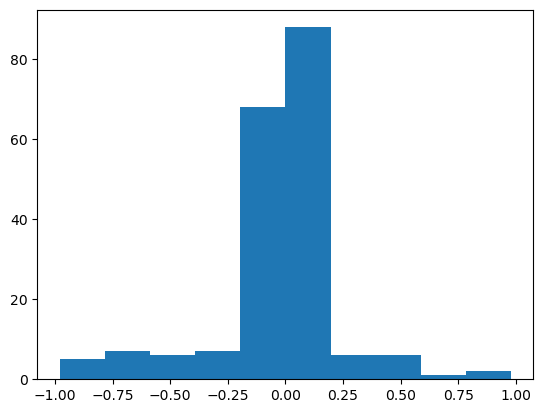

In [149]:
plt.hist(search_SNV_AF_changes)

<Axes: ylabel='SNP'>

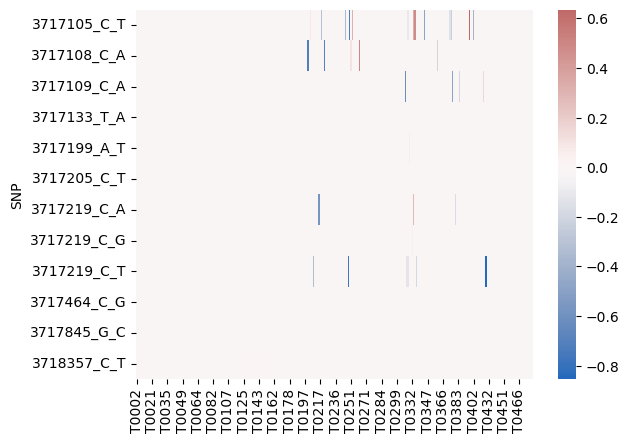

In [118]:
search_SNVs = np.sort(df_variants.query("GENE in ['sugI']").SNP.unique())

sns.heatmap(SNP_differences[search_SNVs].T,
            cmap='vlag',
            center=0
           )

'-'

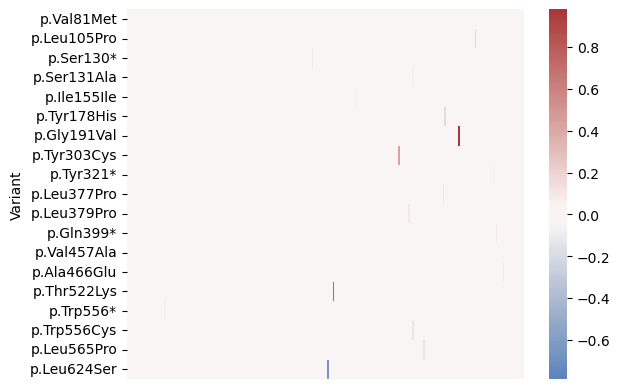

In [136]:
sense = h37Rv_genes.query("Symbol=='Rv2690c'").get('Strand').values[0]

if sense == '+':
    search_SNVs = np.sort(df_variants.query("GENE in ['Rv2690c']").SNP.unique())
else:
    search_SNVs = np.sort(df_variants.query("GENE in ['Rv2690c']").SNP.unique())[::-1]

label_dict = dict(df_variants.query("SNP in @search_SNVs")[['SNP', 'HGVS_P']].drop_duplicates().values)

fig, ax = plt.subplots()

sns.heatmap(SNP_differences[search_SNVs].T,
            cmap='vlag',
            center=0,
            ax=ax
           )

ax.set_yticklabels([label_dict.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()])
ax.set_xticks([])
plt.ylabel('Variant')

plt.show()

<Axes: ylabel='SNP'>

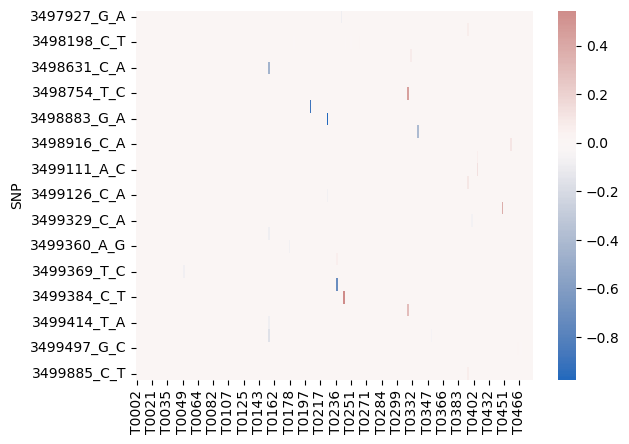

In [117]:
search_SNVs = np.sort(df_variants.query("GENE in ['devR', 'devS']").SNP.unique())

sns.heatmap(SNP_differences[search_SNVs].T,
            cmap='vlag',
            center=0
           )

In [114]:
SNP_differences[search_SNVs].min(axis=0)

SNP
3498198_C_T   -0.005263
3499497_G_C   -0.003333
3498883_G_A   -0.977778
3499126_C_A   -0.074844
3499372_T_C   -0.715139
3499366_A_G    0.000000
3497927_G_A   -0.089835
3499384_C_T    0.000000
3498684_G_A    0.000000
3499360_A_G   -0.069909
3498758_G_T   -0.898305
3498754_T_C    0.000000
3499389_A_G    0.000000
3498241_A_G    0.000000
3498896_G_T   -0.406061
3499543_G_A    0.000000
3499434_A_T   -0.167763
3499329_C_A   -0.061889
3499369_T_C   -0.080488
3498097_A_C    0.000000
3499111_A_T    0.000000
3499885_C_T    0.000000
3499052_C_T    0.000000
3499111_A_C    0.000000
3499141_A_C    0.000000
3498631_C_A   -0.444816
3499350_A_T   -0.090395
3499414_T_A   -0.089172
3498916_C_A    0.000000
dtype: float64

<Axes: ylabel='SNP'>

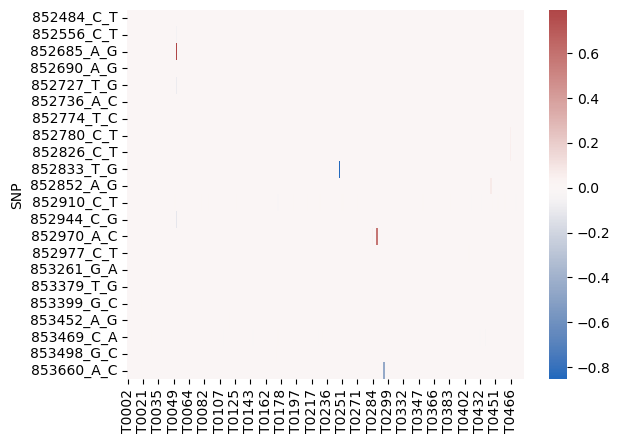

In [119]:
search_SNVs = np.sort(df_variants.query("GENE in ['phoR']").SNP.unique())

sns.heatmap(SNP_differences[search_SNVs].T,
            cmap='vlag',
            center=0
           )

In [181]:
# # lower because of variants at 163705 and 163706, which are often in the range 0.9-0.95 and is why we're doing this exclusion in the first place
# fixed_thresh = 0.9

# mask = (SNP_differences.abs() > fixed_thresh) & ((sample_1_SNPs == 0) | (sample_2_SNPs == 0))

# # Get coordinates (row, col) of matches
# matches = mask.stack()  # converts to Series with MultiIndex
# matches = matches[matches]  # filter True values

# exclude_SNPs = matches.reset_index().iloc[:, :2]
# exclude_SNPs.columns = ['pid', 'SNP']

# print(f"Excluding {len(exclude_SNPs)} (pid, SNP) pairs that are suspicious")

# # replace the values. Make the SNPs fixed in both, and the difference 0
# sample_1_SNPs.mask(mask, other=1, inplace=True)
# sample_2_SNPs.mask(mask, other=1, inplace=True)
# SNP_differences.mask(mask, other=0, inplace=True)

# # Convert to tuples for comparison
# to_exclude = set(exclude_SNPs.itertuples(index=False, name=None))

# # # remove the SNPs from df_variants and df_lowAF_variants
# # df_variants = df_variants[~df_variants[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)]
# # df_lowAF_variants = df_lowAF_variants[~df_lowAF_variants[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)]

# # do the same for the baseline ones?
# # df_variants_baseline, df_lowAF_variants_baseline

In [163]:
df_variants_baseline[df_variants_baseline[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)]

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,Real,False_in_all_Ground_Truth_Samples,predicted,pred_class,Paired_Sample_Num,SNP,Region,Variant_Type,REF_AA,ALT_AA
9804,163705,C,T,10000.0,cyp138,c.340_341delCCinsTT,p.Pro114Phe,1,351,351.00,...,NaN,NaN,NaN,NaN,1,163705_C_T,cyp138,Missense,Pro,Phe
9805,163706,C,T,10000.0,cyp138,c.340_341delCCinsTT,p.Pro114Phe,1,351,351.00,...,NaN,NaN,NaN,NaN,1,163706_C_T,cyp138,Missense,Pro,Phe
15222,163705,C,T,8100.0,cyp138,c.340_341delCCinsTT,p.Pro114Phe,1,285,285.00,...,NaN,NaN,NaN,NaN,1,163705_C_T,cyp138,Missense,Pro,Phe
15223,163706,C,T,8100.0,cyp138,c.340_341delCCinsTT,p.Pro114Phe,1,285,285.00,...,NaN,NaN,NaN,NaN,1,163706_C_T,cyp138,Missense,Pro,Phe
17562,3296843,A,G,5500.0,pks15,c.998T>C,p.Val333Ala,1,181,181.00,...,NaN,NaN,NaN,NaN,1,3296843_A_G,pks15,Missense,Val,Ala
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371878,3009842,C,T,10000.0,ceoB,c.499C>T,p.Gln167*,1,298,298.00,...,NaN,NaN,NaN,NaN,1,3009842_C_T,ceoB,Nonsense,Gln,67*
375313,1774659,C,T,13000.0,Rv1566c-Rv1567c,n.1774659C>T,NaN,1,377,385.00,...,NaN,NaN,NaN,NaN,1,1774659_C_T,NC_1228,Intergenic,NaN,NaN
377845,2211834,G,C,7700.0,mce3C,c.209G>C,p.Ser70Thr,1,268,268.00,...,NaN,0.0,0.999968,1.0,1,2211834_G_C,mce3C,Missense,Ser,Thr
378173,2057774,A,T,9700.0,Rv1815,c.247A>T,p.Ile83Phe,1,282,282.40,...,NaN,NaN,NaN,NaN,1,2057774_A_T,Rv1815,Missense,Ile,Phe


In [169]:
df_lowAF_variants_baseline[df_lowAF_variants_baseline[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)][['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF']]

,pid,SampleID,POS,REF,ALT,AF
302,T0330,MFS-395,3538227,C,T,0.921659
470,T0067,MFS-551,295718,C,T,0.940860
699,T0132,MFS-743,226517,C,T,0.929664
705,T0175,MFS-751,4080979,A,G,0.938547
840,T0428,MFS-890,2211834,G,C,0.902985
843,T0450,MFS-892,226517,C,T,0.941176


In [171]:
df_lowAF_variants_baseline.query("pid=='T0330'")[['SampleID']]

,SampleID
299,MFS-395
300,MFS-395
301,MFS-395
302,MFS-395
303,MFS-395
304,MFS-395


In [11]:
df_variants_baseline[df_variants_baseline[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)].GENE.value_counts()

GENE
pks15      23
Rv3433c    20
cyp138     14
Rv0376c    13
ltp4       12
           ..
proB        1
uvrC        1
Rv2047c     1
pks5        1
mce3C       1
Name: count, Length: 83, dtype: int64

In [8]:
df_variants.AF.min(), df_variants.AF.max()

(0.05, 1.0)

In [9]:
df_lowAF_variants.AF.min(), df_lowAF_variants.AF.max()

(0.05, 0.95)

In [98]:
df_lowAF_variants_baseline.GENE.value_counts()

GENE
sugI       26
devR       10
phoR        9
Rv2690c     9
devS        7
           ..
aftB        1
lipF        1
Rv3108      1
Rv2414c     1
Rv2819c     1
Name: count, Length: 625, dtype: int64

In [10]:
df_lowAF_variants.drop_duplicates(subset='POS').Variant_Type.value_counts()

Variant_Type
Missense      700
Silent        273
Intergenic    122
Nonsense       20
Stop_Lost       7
Start_Lost      2
Name: count, dtype: int64

In [11]:
df_lowAF_variants.GENE.value_counts().head(10)

GENE
sugI       35
Rv2690c    16
devS       13
phoR       12
devR       12
Rv2781c    10
subI        8
Rv0193c     8
hycP        8
Rv0273c     8
Name: count, dtype: int64

In [137]:
df_lowAF_variants.query("Variant_Type=='Nonsense'").GENE.value_counts()

GENE
sugI       15
Rv2690c     4
pks7        1
fadE3       1
glnA2       1
PPE50       1
pepN        1
rpsO        1
Rv1473      1
Rv1767      1
hycQ        1
ceoB        1
Rv2628      1
eccD1       1
Rv2943      1
ppsC        1
devR        1
Name: count, dtype: int64

In [168]:
df_lowAF_variants.query("GENE in ['phoR']")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'Variant_Type']].merge(df_ground_truth_lowAF_SNPs[['SampleID']].drop_duplicates())

,pid,SampleID,POS,REF,ALT,AF,Variant_Type
0,T0249,MFS-162,852833,T,G,0.852000,Missense
1,T0284,MFS-325,852970,A,C,0.678201,Missense
2,T0284,MFS-326,852970,A,C,0.720524,Missense


In [171]:
df_lowAF_variants.query("GENE in ['phoR']")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'Variant_Type', 'Coll2014']]

,pid,SampleID,POS,REF,ALT,AF,Variant_Type,Coll2014
118,T0249,MFS-162,852833,T,G,0.852000,Missense,2.2.1
244,T0294,MFS-282,853660,A,C,0.452555,Missense,2.2.1.1
301,T0052,MFS-30,852556,C,T,0.061224,Missense,2.2.1.1
302,T0052,MFS-30,852685,A,G,0.208661,Missense,2.2.1.1
303,T0052,MFS-30,852727,T,G,0.091575,Missense,2.2.1.1
304,T0052,MFS-30,852944,C,G,0.120000,Missense,2.2.1.1
313,T0288,MFS-306,852970,A,C,0.577236,Missense,2.2.1.1
344,T0284,MFS-325,852970,A,C,0.678201,Missense,2.2.1.1
351,T0284,MFS-326,852970,A,C,0.720524,Missense,2.2.1.1
1234,T0466,MFS-851,852780,C,T,0.051181,Missense,4.4.1.1


In [148]:
df_lowAF_variants.query("GENE in ['PPE50']")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'Variant_Type']]

,pid,SampleID,POS,REF,ALT,AF,Variant_Type
455,T0329,MFS-393,3501679,G,A,0.076364,Missense
465,T0330,MFS-395,3501679,G,A,0.068966,Missense
1015,T0175,MFS-752,3501504,G,A,0.177419,Nonsense


In [164]:
df_ground_truth_lowAF_SNPs.query("SampleID=='MFS-395'")[['SampleID', 'POS', 'REF', 'ALT', 'AF']]

,SampleID,POS,REF,ALT,AF
0,MFS-395,1020262,A,G,0.098592
1,MFS-395,3449820,G,A,0.054902
2,MFS-395,3501679,G,A,0.063158
3,MFS-395,3538227,T,C,0.068807
4,MFS-395,3717199,A,T,0.063636
5,MFS-395,4377088,G,A,0.077778


In [154]:
df_trust_patients.query("pid in ['T0329', 'T0330']")[['pid', 'bl_housecode', 'bl_household', 'bl_houseclose']]

,pid,bl_housecode,bl_household,bl_houseclose
70,T0329,NaN,0,0
71,T0329,NaN,0,0
426,T0330,NaN,0,0
427,T0330,NaN,0,0
428,T0330,NaN,0,0


In [153]:
df_trust_patients.columns[df_trust_patients.columns.str.contains('bl_house')]

Index(['bl_household', 'bl_housecode', 'bl_houseclose', 'bl_houseclosenum',
       'bl_houseclose_1code', 'bl_houseclose_1type', 'bl_houseclose_2code',
       'bl_houseclose_2type'],
      dtype='object')

In [ ]:
df_lowAF_variants.query("Variant_Type=='Nonsense' & GENE=='sugI'").pid.nunique()

13

In [ ]:
df_lowAF_variants.query("Variant_Type=='Nonsense' & GENE=='Rv2690c'").pid.nunique()

4

# Selecting a Diversity Metric

In [12]:
AF_lst = np.linspace(0.005, 0.995, 101)

df_test = pd.DataFrame({'AF': AF_lst})
# df_test['Product'] = df_test['AF'] * (1 - df_test['AF'])
# df_test['Gini_Impurity'] = 1 - df_test['AF']**2 - (1 - df_test['AF'])**2
df_test['Shannon_Entropy'] = - df_test['AF'] * np.log2(df_test['AF']) - (1 - df_test['AF']) * np.log2(1 - df_test['AF'])

df_test = df_test.melt(id_vars='AF')

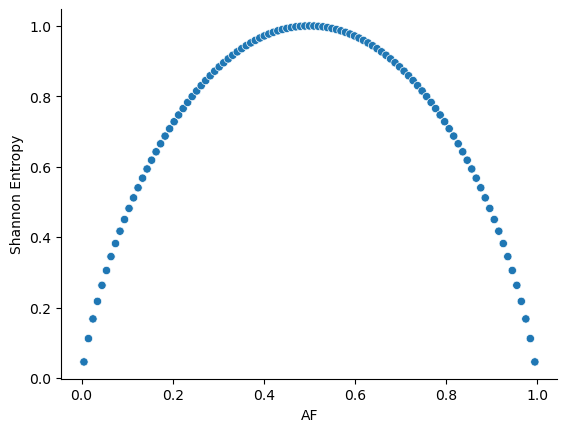

In [19]:
sns.scatterplot(data=df_test,
                x='AF',
                y='value',
                hue='variable',
                legend=False
               )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Product',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Gini_Impurity',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Shannon_Entropy',
#                 # legend=False
#                )

# plt.legend(title='')

plt.xlabel('AF')
plt.ylabel('Shannon Entropy')
# plt.title(f"Product of AF and (1 - AF)")
sns.despine()
plt.savefig("../results/figures/Shannon_Entropy_example.svg")

In [215]:
def LAF_metric(AF_series, AF_min=0.05, AF_max=0.95):
    
    # the series has the SNP names as the indexes
    AF_array = AF_series.values
    
    # exclude absent or fixed variants from the count of low frequency variants
    keep_idx = np.argwhere((AF_array >= AF_min) & (AF_array <= AF_max)).flatten()
    keep_variants = AF_series.iloc[keep_idx].index.values

    # exclude 0s because those are no variants. It's because it's from a matrix, all positions that have a variant anywhere are there
    # any zeroes or ones (zeroes because 1 - AF) will zero out the Shannon entropy
    AF_array = AF_array[(AF_array >= AF_min) & (AF_array <= AF_max)]
    
    if len(AF_array) == 0:
        return [], 0, 0

    LAF = 0

    for i, AF in enumerate(AF_array):        
        # shannon entropy
        LAF += - AF * np.log2(AF) - (1 - AF) * np.log2(1 - AF)

    # return mean Shannon entropy. Also return the number of variable sites
    return keep_variants, LAF, LAF / len(AF_array)


def compute_proportion_variable_sites_shared_2samples(pid, df):
    
    df_sample_1 = df.query("pid == @pid & Paired_Sample_Num == 1")
    df_sample_2 = df.query("pid == @pid & Paired_Sample_Num == 2")
    
    sites_variable_intersect = list(set(df_sample_1.POS).intersection(df_sample_2.POS))
    sites_variable_union = list(set(df_sample_1.POS).union(df_sample_2.POS))
    
    if len(sites_variable_union) == 0:
        return 0
    
    # return proportion of all variable sites that are common between the two samples
    return len(sites_variable_intersect) / len(sites_variable_union)

In [216]:
def compute_diversity_metric_changes(sample_1_SNPs, sample_2_SNPs, SNP_differences, df_pids, silent_SNPs, AF_thresh=0.95, silent=True):

    # segregating sites is symmetric difference between sample 1 and sample 2. These are the sites that are different between them?
    df_LAF = pd.DataFrame(columns = ['pid', 'SE1', 'SE2', 'SASE1', 'SASE2', 'NumVar1', 'NumVar2', 'NumVar', 'OverlapVarSites', 'ChangeSites'])
    
    if not silent:
        sample_1_SNPs = sample_1_SNPs.drop(columns=silent_SNPs)
        sample_2_SNPs = sample_2_SNPs.drop(columns=silent_SNPs)
        SNP_differences = SNP_differences.drop(columns=silent_SNPs)
        
    print(SNP_differences.shape)

    for i, pid in enumerate(sample_1_SNPs.index.values):

        # remove sites that are fixed (AF > AF_thresh) in both. Keep those that are fixed in one and not the other though
        single_pid_results = pd.DataFrame(SNP_differences.loc[pid]).query(f"{pid} != 0").merge(pd.DataFrame(sample_1_SNPs.loc[pid]).rename(columns={pid: 'Sample1'}), left_index=True, right_index=True)
        single_pid_results = single_pid_results.merge(pd.DataFrame(sample_2_SNPs.loc[pid]).rename(columns={pid: 'Sample2'}), left_index=True, right_index=True)
        single_pid_results = single_pid_results.query("~(Sample1 > @AF_thresh & Sample2 > @AF_thresh)")

        sample_1_variable_sites, sample_1_SE, sample_1_SASE = LAF_metric(single_pid_results['Sample1'], AF_min=0.05, AF_max=AF_thresh)
        sample_2_variable_sites, sample_2_SE, sample_2_SASE = LAF_metric(single_pid_results['Sample2'], AF_min=0.05, AF_max=AF_thresh)

        df_LAF.loc[i, :] = [pid, 
                            sample_2_SE, # Shannon entropy for sample 1
                            sample_2_SE, # Shannon entropy for sample 2
                            sample_1_SASE,
                            sample_2_SASE,
                            len(sample_1_variable_sites), # number of variable sites for sample 1
                            len(sample_2_variable_sites), # number of variable sites for sample 2
                            len(list(set(sample_1_variable_sites).union(sample_2_variable_sites))), # union of variable sites in samples 1 and 2
                            len(list(set(sample_1_variable_sites).intersection(sample_2_variable_sites))),
                            len(list(set(sample_1_variable_sites).symmetric_difference(sample_2_variable_sites))), # non-overlapping set of sites from samples 1 and 2 
                           ]

    # add in pids that are not in sample_1_unfixed_SNPs, which don't have a low frequency metric anywhere
    pids_no_LAF_variants = list(set(df_pids.pid) - set(df_LAF.pid))
    df_pids_no_LAF_variants = pd.DataFrame(columns = df_LAF.columns)
    df_pids_no_LAF_variants['pid'] = pids_no_LAF_variants

    for col in df_pids_no_LAF_variants.columns:
        if col != 'pid':
            df_pids_no_LAF_variants[col] = 0

    df_LAF = pd.concat([df_LAF, df_pids_no_LAF_variants])

    df_LAF['SE_Diff'] = df_LAF['SE2'] - df_LAF['SE1']
    df_LAF['SASE_Diff'] = df_LAF['SASE2'] - df_LAF['SASE1']
    df_LAF['Abs_SASE_Diff'] = np.abs(df_LAF['SASE_Diff'])

    df_LAF = df_LAF.merge(df_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']].drop_duplicates(subset='pid'))
    # df_LAF['Lineage'] = df_LAF['Lineage'].astype(int)
    df_LAF['NumVarDiff'] = df_LAF['NumVar2'] - df_LAF['NumVar1']

    df_LAF.to_csv(f"../results/diversity_metrics_{df_LAF.pid.nunique()}pids.csv", index=False)

    df_lowAF_variants.to_csv(f"../results/lowAF_variants_{df_lowAF_variants.pid.nunique()}pids.csv", index=False)
    
    return df_LAF
    
    
    
    
def compute_diversity_metric_baseline(sample_1_SNPs, df_pids, silent_SNPs, AF_thresh=0.95, silent=True):

    # segregating sites is symmetric difference between sample 1 and sample 2. These are the sites that are different between them?
    df_LAF = pd.DataFrame(columns = ['pid', 'SE1', 'SASE1', 'NumVar1'])
    
    if not silent:
        sample_1_SNPs = sample_1_SNPs.drop(columns=list(set(silent_SNPs).intersection(sample_1_SNPs.columns)))
        
    print(sample_1_SNPs.shape)

    for i, pid in enumerate(sample_1_SNPs.index.values):

        sample_1_variable_sites, sample_1_SE, sample_1_SASE = LAF_metric(sample_1_SNPs_baseline.loc[pid, :], AF_min=0.05, AF_max=AF_thresh)

        df_LAF.loc[i, :] = [pid, 
                            sample_1_SE, # Shannon entropy for sample 1
                            sample_1_SASE,
                            len(sample_1_variable_sites), # number of variable sites for sample 1
                           ]

    # add in pids that are not in sample_1_unfixed_SNPs, which don't have a low frequency metric anywhere
    pids_no_LAF_variants = list(set(df_pids.pid) - set(df_LAF.pid))
    df_pids_no_LAF_variants = pd.DataFrame(columns = df_LAF.columns)
    df_pids_no_LAF_variants['pid'] = pids_no_LAF_variants

    for col in df_pids_no_LAF_variants.columns:
        if col != 'pid':
            df_pids_no_LAF_variants[col] = 0

    df_LAF = pd.concat([df_LAF, df_pids_no_LAF_variants])

    df_LAF = df_LAF.merge(df_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']].drop_duplicates(subset='pid'))

    return df_LAF

In [217]:
df_LAF = compute_diversity_metric_changes(sample_1_SNPs, 
                                          sample_2_SNPs, 
                                          SNP_differences, 
                                          df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"), 
                                          df_variants.query("Variant_Type == 'Silent'").SNP.unique(), 
                                          silent=False
                                         )

# df_LAF_with_silent = compute_diversity_metric_changes(sample_1_SNPs, 
#                                                       sample_2_SNPs, 
#                                                       SNP_differences, 
#                                                       df_longitudinal_pids,#.query("pid in @pids_with_same_lineage_and_low_F2"), 
#                                                       silent_SNPs, 
#                                                       silent=True
#                                                      )


df_LAF_baseline = compute_diversity_metric_baseline(sample_1_SNPs_baseline, 
                                                    df_baseline_samples, 
                                                    df_variants_baseline.query("Variant_Type=='Silent'").SNP.unique(), 
                                                    silent=False
                                                   )

(285, 7950)
(395, 9217)


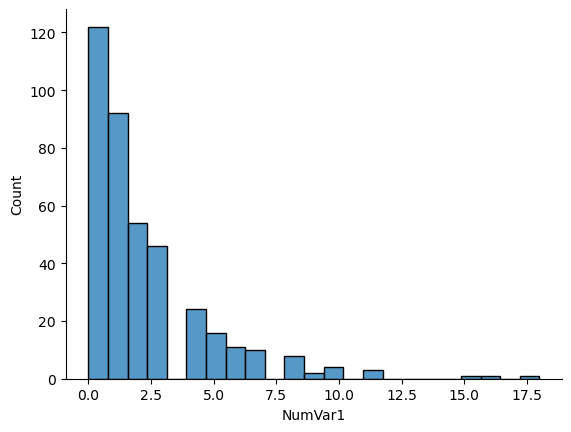

In [21]:
sns.histplot(data=df_LAF_baseline,
             x='NumVar1'
            )

sns.despine()
plt.show()

In [18]:
# sns.scatterplot(data=df_LAF_baseline,
#                 x='F2',
#                  y='SASE1'
#                 )

# plt.axvline(F2_max, color='black', linestyle='--', linewidth=1, label=f"F2 = {F2_max}")

# plt.xscale('log')
# plt.yscale('log')

# plt.ylabel('Shannon Entropy')
# plt.legend()

# sns.despine()

In [22]:
# or ttest_rel for parametric
st.wilcoxon(df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")['SASE2'],
            df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")['SASE1'],
            alternative='greater'
           )

WilcoxonResult(statistic=13559.0, pvalue=0.2656872723634476)

In [23]:
df_LAF.query("pid in @pids_with_same_lineage_and_low_F2").SASE_Diff.median(), df_LAF.query("pid in @pids_with_same_lineage_and_low_F2").SASE_Diff.mean()

(0.0, 0.009452494091769922)

In [24]:
# or ttest_rel for parametric
st.wilcoxon(df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")['NumVar2'],
            df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")['NumVar1'],
            alternative='greater'
           )

WilcoxonResult(statistic=11866.5, pvalue=0.005559314500998942)

In [233]:
# or ttest_rel for parametric
st.wilcoxon(df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")['NumVarDiff'],
            alternative='greater'
           )

WilcoxonResult(statistic=11874.0, pvalue=0.0035483067743268333)

In [229]:
df_LAF.query("pid in @pids_with_same_lineage_and_low_F2").NumVarDiff.median(), df_LAF.query("pid in @pids_with_same_lineage_and_low_F2").NumVarDiff.mean()

(0.0, 0.35789473684210527)

In [230]:
len(df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")), len(df_LAF.query("pid in @pids_with_same_lineage_and_low_F2 & NumVar1==0 & NumVar2==0"))

(285, 59)

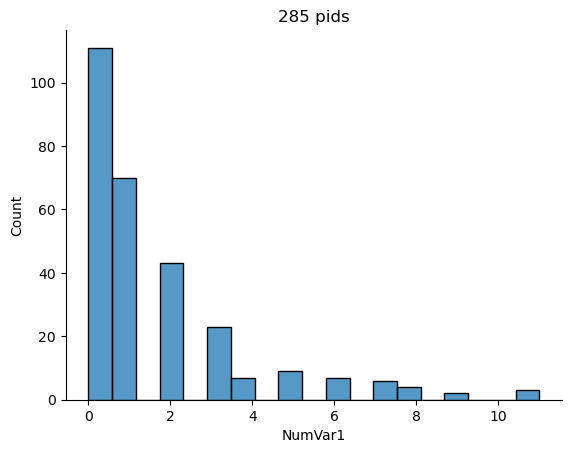

In [25]:
df_plot = df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")

sns.histplot(data=df_plot,
             x='NumVar1',
            )

plt.title(f"{df_plot.pid.nunique()} pids")

sns.despine()
plt.savefig("../results/figures/NumVar1_unmixed.svg", bbox_inches='tight')

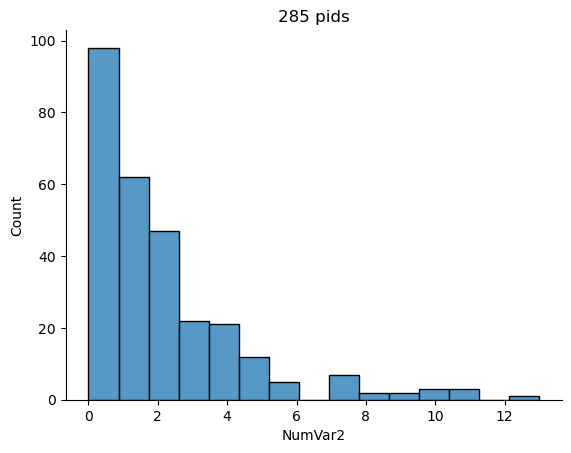

In [26]:
df_plot = df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")

sns.histplot(data=df_plot,
             x='NumVar2',
            )

plt.title(f"{df_plot.pid.nunique()} pids")

sns.despine()
plt.savefig("../results/figures/NumVar2_unmixed.svg", bbox_inches='tight')

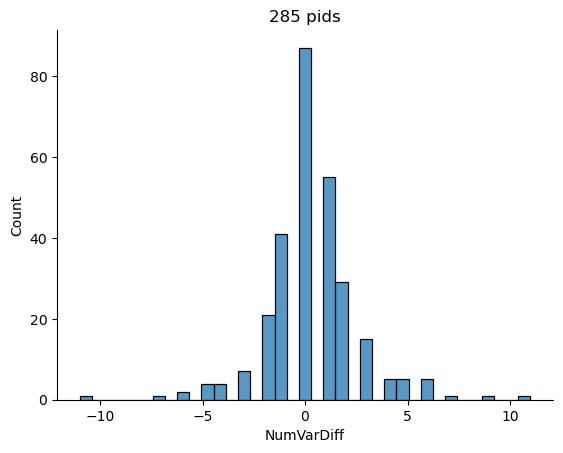

In [27]:
df_plot = df_LAF.query("pid in @pids_with_same_lineage_and_low_F2")

sns.histplot(data=df_plot,
             x='NumVarDiff',
            )

plt.title(f"{df_plot.pid.nunique()} pids")

sns.despine()
plt.savefig("../results/figures/NumVardiff_unmixed_both.svg", bbox_inches='tight')

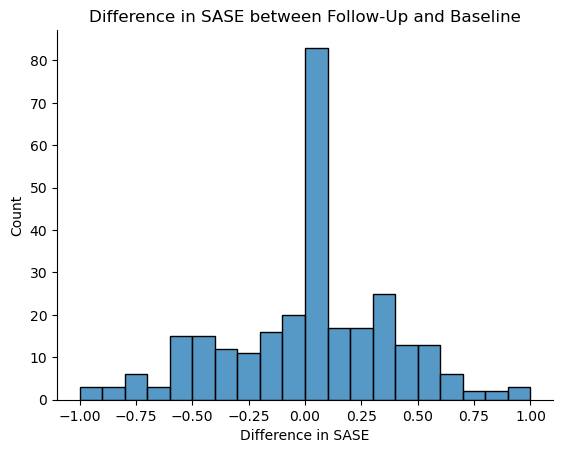

In [28]:
sns.histplot(data=df_LAF.query("pid in @pids_with_same_lineage_and_low_F2"),
             x='SASE_Diff',
             bins=np.linspace(-1, 1, 21)
            )

plt.title('Difference in SASE between Follow-Up and Baseline')
plt.xlabel('Difference in SASE')

sns.despine()
plt.savefig("../results/figures/SASE_diff.svg", bbox_inches='tight')

In [29]:
lineage_col = 'Coll2014'

for lineage in df_LAF[lineage_col].unique():
    
    num_isolates = len(df_LAF.query(f"{lineage_col}==@lineage & ~(SASE1 == 0 & SASE2 == 0)"))
    
    if num_isolates > 1:
    
        increase_pval = st.wilcoxon(df_LAF.query(f"{lineage_col}==@lineage")['SASE2'],
                                    df_LAF.query(f"{lineage_col}==@lineage")['SASE1'],
                                    alternative='greater'
                                   ).pvalue
        
        decrease_pval = st.wilcoxon(df_LAF.query(f"{lineage_col}==@lineage")['SASE2'],
                                    df_LAF.query(f"{lineage_col}==@lineage")['SASE1'],
                                    alternative='less'
                                   ).pvalue

        if increase_pval <= 0.05:
            print(f"L{lineage} increase: p = {np.round(increase_pval, 2)}, N = {num_isolates}")
            
        if decrease_pval <= 0.05:
            print(f"L{lineage} decrease: p = {np.round(decrease_pval, 2)}, N = {num_isolates}")

L4.1.2.1 increase: p = 0.03, N = 4


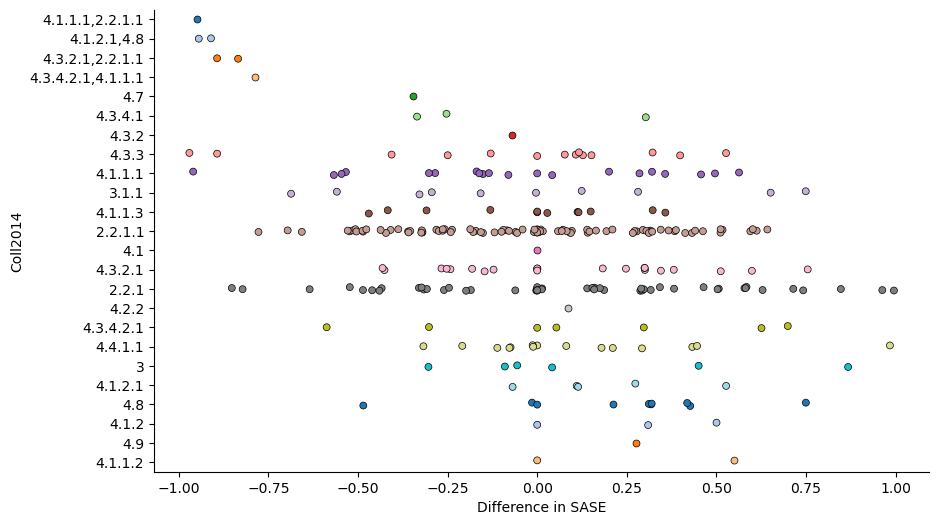

In [353]:
lineage_order = df_LAF.groupby('Coll2014')['SASE_Diff'].mean().sort_values().index.values

fig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(data=df_LAF,
                x='SASE_Diff',
             y='Coll2014',
             # multiple='dodge',
             # common_norm=False,
             palette='tab20',
              order=lineage_order,
              edgecolor='black',
              linewidth=0.5,
              ax=ax
               )

# plt.title('Difference in SASE between Follow-Up and Baseline')
plt.xlabel('Difference in SASE')

sns.despine()
# plt.savefig("../results/figures/SASE_diff_by_lineage.svg", bbox_inches='tight')

Text(0.5, 1.0, 'Absolute Change in SASE vs. Number of Sites with Low AF Variants')

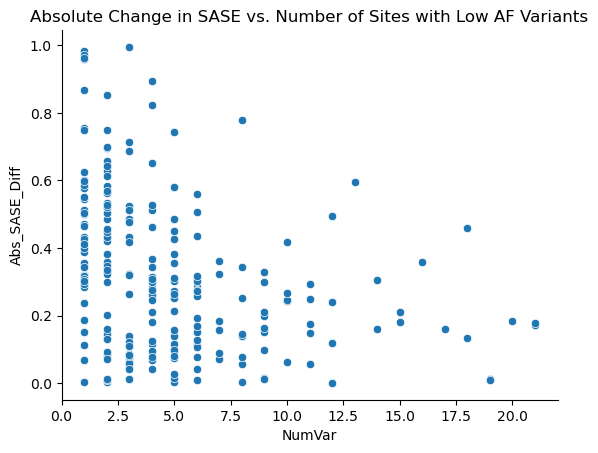

In [354]:
sns.scatterplot(data=df_LAF.query("pid in @pids_with_low_F2").query("SASE1 != 0 | SASE2 != 0"),
                x='NumVar',
                y='Abs_SASE_Diff'
               )

# plt.yscale('log')

sns.despine()
plt.title("Absolute Change in SASE vs. Number of Sites with Low AF Variants")

In [355]:
st.spearmanr(df_LAF.query("pid in @pids_with_low_F2").query("SASE1 != 0 | SASE2 != 0")['NumVar'], df_LAF.query("pid in @pids_with_low_F2").query("SASE1 != 0 | SASE2 != 0")['Abs_SASE_Diff'])

SignificanceResult(statistic=-0.3959760196258482, pvalue=2.1385435171114255e-10)

# pids with Large Changes in SASE

In [31]:
# pid = 'T0143'

# # remove sites that are fixed (AF > 0.95) in both. Keep those that are fixed in one and not the other though
# single_pid_results = pd.DataFrame(SNP_differences.loc[pid]).query(f"{pid} != 0").merge(pd.DataFrame(sample_1_SNPs.loc[pid]).rename(columns={pid: 'Sample1'}), left_index=True, right_index=True)
# single_pid_results = single_pid_results.merge(pd.DataFrame(sample_2_SNPs.loc[pid]).rename(columns={pid: 'Sample2'}), left_index=True, right_index=True)
# single_pid_results = single_pid_results.query("~(Sample1 > @AF_thresh & Sample2 > @AF_thresh)")

# single_pid_results

# Nucleotide Diversity and Estimated Population Size Calculations

In [ ]:
# df_exclude = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_regions_50bp.EBRlessThan95Percent.bed", sep='\t', header=None)

# excluded_sites = []

# for i, row in df_exclude.iterrows():
#     excluded_sites += list(np.arange(row[1] + 1, row[2] + 1))
    
# # also excluded [2337869, 2340874], inclusive
# excluded_sites += list(np.arange(2337869, 2340874 + 1))

# excluded_sites = np.unique(excluded_sites)

# num_total_sites = len(h37Rv_seq) - len(excluded_sites)

In [360]:
def compute_nucleotide_diversity_Ne(pid, mutation_rate=5e-8):
    
    # remove sites that are fixed (AF > 0.95) in both. Keep those that are fixed in one and not the other though
    df_sample_1 = pd.DataFrame(sample_1_SNPs.loc[pid]).rename(columns={pid: 'Sample1'})
    df_sample_2 = pd.DataFrame(sample_2_SNPs.loc[pid]).rename(columns={pid: 'Sample2'})

    df_sample_1['Sample1_Inv'] = 1 - df_sample_1['Sample1']
    df_sample_2['Sample2_Inv'] = 1 - df_sample_2['Sample2']

    ND_1 = np.sum(2 * df_sample_1.product(axis=1)) / len(df_sample_1)
    ND_2 = np.sum(2 * df_sample_2.product(axis=1)) / len(df_sample_2)

    Ne_1 = ND_1 / (2 * mutation_rate)
    Ne_2 = ND_2 / (2 * mutation_rate)

    return pd.DataFrame({'pid': pid, 'ND_1': ND_1, 'ND_2': ND_2, 'Ne_1': Ne_1, 'Ne_2': Ne_2}, index=[0])

In [368]:
df_population_sizes = []

for pid in df_longitudinal_pids.pid.unique():
    df_population_sizes.append(compute_nucleotide_diversity_Ne(pid))
    
df_population_sizes = pd.concat(df_population_sizes)

print(np.round(df_population_sizes[['Ne_1', 'Ne_2']].max().max()))

df_population_sizes = df_population_sizes.merge(df_longitudinal_pids[['pid', 'Paired_Sample_Num', 'F2']].pivot(index='pid', columns='Paired_Sample_Num', values='F2').rename(columns={1: 'F2_1', 2: 'F2_2'}).reset_index())

437980.0


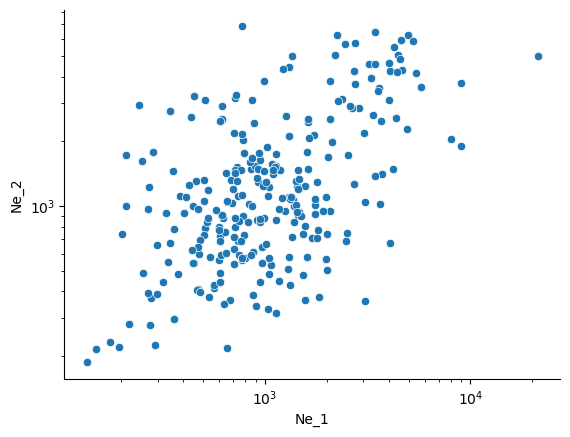

In [371]:
sns.scatterplot(data=df_population_sizes.query("pid in @pids_with_low_F2"),
                x='Ne_1',
                y='Ne_2'
               )

plt.xscale('log')
plt.yscale('log')

sns.despine()

# Associate diversity metrics with outcomes

In [218]:
import sys
sys.path.append(os.path.join(os.getcwd(), "scripts"))
from epi_utils import *

In [434]:
cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            # 'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'adherence_rate_by_observed',
            'high_lung_involvement',
            'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
            # 'F2',
            # 'MixedInfect'
           ]


# try these first, as they were required for the full TCC model
stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'HIV_CD4', 'smoked_substance_use', 'screen_sex', 'high_lung_involvement']

non_linear_term_variables = []

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv").query("pid in @df_trust_patients.pid")

df_TCC = df_imputed_TCC.query("imp_num==0").reset_index(drop=True)
df_imputed_TCC = df_imputed_TCC.query("imp_num > 0").reset_index(drop=True)

CNN_results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

# this includes TTP, PK AUC, and CXR data merged in
df_processed_patients = pd.read_csv(f"{TRUST_data_dir}/20251125_cleaned_patient_outcomes_data.csv")

df_pids_for_outcomes_model, TRUST_phenos, df_pred_combined = read_combine_all_TRUST_data(df_processed_patients, 
                                                                                         {'RIF': 'lineage_amino_acid',
                                                                                          'INH': 'lineage_amino_acid',
                                                                                          'EMB': 'lineage_amino_acid',
                                                                                          'PZA': 'amino_acid'}, 
                                                                                         CNN_results_dir,
                                                                                         F2_thresh=1, 
                                                                                         baseline_only=True
                                                                                        )

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_longitudinal_pids.pid").drop_duplicates(subset='pid').reset_index(drop=True)
# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_baseline_samples.pid").drop_duplicates(subset='pid').reset_index(drop=True)

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @pids_with_same_lineage_and_low_F2").drop_duplicates(subset='pid').reset_index(drop=True)
# df_pids_for_outcomes_model = df_pids_for_outcomes_model.drop_duplicates(subset='pid').reset_index(drop=True)

df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_baseline_samples.pid & Sampling_Week <= 2")
df_pids_for_outcomes_model['inh_resistant'] = (df_pids_for_outcomes_model['pid'].isin(TRUST_phenos.query("INH_lower_bound >= 0.1").pid.values)).astype(int)

df_pids_for_outcomes_model['underweight'] = (df_pids_for_outcomes_model['bl_bmi'] < 18).astype(int)
df_pids_for_outcomes_model['MixedInfect'] = (df_pids_for_outcomes_model['F2'] > F2_max).astype(int)
df_pids_for_outcomes_model['High_TTP'] = (df_pids_for_outcomes_model['TTP_baseline'] > 300).astype(int)

# df_pids_for_outcomes_model['inv_adherence_rate_by_observed'] = 1 - df_pids_for_outcomes_model['adherence_rate_by_observed']

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("Sampling_Week <= 2")
df_pids_for_outcomes_model = df_pids_for_outcomes_model.sort_values(['pid', 'Original_ID']).drop_duplicates(subset='pid', keep='first').reset_index(drop=True)

len(df_pids_for_outcomes_model), df_pids_for_outcomes_model.pid.nunique()

406 patients with uncontaminated WGS samples
400 patients with uncontaminated WGS samples taken in the first 2 weeks

8 patients: ['T0402' 'T0206' 'T0128' 'T0042' 'T0404' 'T0032' 'T0403' 'T0170'] have multiple sequences at the same timepoint
403 patients have MICs for RIF
403 patients have MICs for INH
403 patients have MICs for EMB
282 patients have MICs for PZA
398 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 400 pids
Found predicted INH MICs for 400 pids
Found predicted EMB MICs for 400 pids
Found predicted PZA MICs for 400 pids
400 patients have predicted MICs


(379, 379)

In [349]:
df_pids_for_outcomes_model['adherence_rate_by_observed'].mean(), df_pids_for_outcomes_model['adherence_rate_by_observed'].median()

(0.7341972046627192, 0.837722337722338)

In [426]:
# df_processed_patients = pd.read_csv(f"/home/sak0914/TRUST_data_processing/processed_data/.snapshot/o2_home_2025-11-24_17_15_04_UTC/20251111_cleaned_patient_outcomes_data.csv")
# df_processed_patients['screen_sex'] = df_processed_patients['screen_sex'].replace(2, 0)
# df_processed_patients.to_csv(f"/home/sak0914/TRUST_data_processing/processed_data/20251111_cleaned_patient_outcomes_data.csv", index=False)

In [457]:
median_survival_imputations = {}

# Prepare a list to collect survival functions from each imputation
survival_curves = []

# Fit Kaplan-Meier for each imputation and store survival function
for imp in df_imputed_TCC['imp_num'].unique():
    
    if imp > 0:
        imputed_data = df_imputed_TCC.query("imp_num==@imp")

        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(durations=imputed_data['TCC'], event_observed=imputed_data['culture_convert'])

        survival_curves.append(kmf.survival_function_.rename(columns={"KM_estimate": f"imp_{imp}"}))

        median_survival_imputations[imp] = kmf.median_survival_time_

# Combine all imputed survival functions into one DataFrame
df_survival = pd.concat(survival_curves, axis=1)

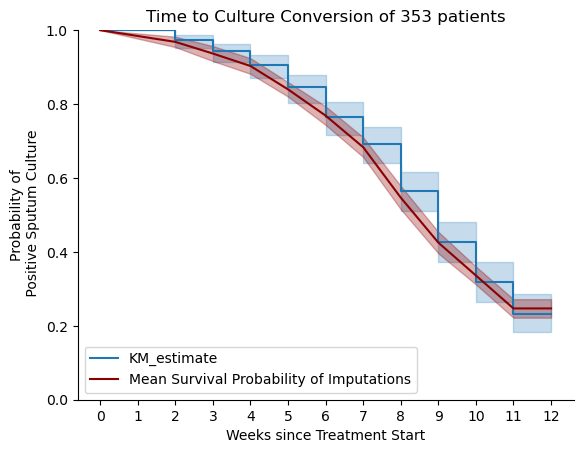

In [460]:
kmf_full_dataset = lifelines.KaplanMeierFitter()
kmf_full_dataset.fit(df_TCC['TCC'], event_observed=df_TCC['culture_convert'])

fig, ax = plt.subplots()

kmf_full_dataset.plot_survival_function()#show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, df_imputed_TCC.TCC.max() + 1))

mean_survival = df_survival.mean(axis=1)
sd_survival = df_survival.std(axis=1)

# plot the mean survival probability at each week across the imputations
# plt.step(df_survival.index, mean_survival, label='KM Estimate of Imputed Datasets', where='post')
plt.plot(df_survival.index, mean_survival, label='Mean Survival Probability of Imputations', color='darkred')#, where='post')

# Calculate and plot the confidence interval using 1.96 * std for ~95% CI
ci_upper = mean_survival + 1.96 * sd_survival
ci_lower = mean_survival - 1.96 * sd_survival

# 'tab:blue'
plt.fill_between(df_survival.index, ci_lower, ci_upper, alpha=0.3, color='darkred')#, label='95% CI')

plt.title(f"Time to Culture Conversion of {df_imputed_TCC.pid.nunique()} patients")
plt.ylabel("Probability of\n Positive Sputum Culture") #
plt.xlabel("Weeks since Treatment Start")

plt.gca().get_legend().remove()
plt.legend()

sns.despine()
plt.savefig(f"/home/sak0914/MtbLongitudinalDiversity/results/figures/TCC/KM_estimate.svg", bbox_inches='tight')

In [436]:
df_test_results, df_model_processed, cph_models_imputations = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                  df_imputed_TCC,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                 MIC_type = 'none',
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True
                                                                                                 )

df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

print(len(df_violating_covariates.query("p <= 0.05")))

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'
df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    328 total pids
0


In [440]:
OR_col = 'HR_TCC_assoc'
df_test_results.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

,pval,covariate,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
6,0.000427,screen_years,1.133511,1.320283,1.53783


In [449]:
diversity_metric = 'NumVar1'
binarize = False
thresh = 0.1

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric, 'grouped_variant']])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

if binarize:
    df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
    
    median_val = df_add_metric_for_model[diversity_metric].median()
    # df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > median_val).astype(int)

df_test_results_diversity, _, _ = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                              df_pred_combined, 
                                                                TRUST_phenos,
                                                              df_imputed_TCC,
                                                           cols_lst + [diversity_metric],
                                                              event_col = 'culture_convert',
                                                              time_col = 'TCC',
                                                              invert_OR=True,
                                                              stratify_variables=stratify_covariates,
                                                             binary_lineage=True
                                                             )

    328 total pids


In [454]:
OR_col = 'HR_TCC_assoc'

df_test_results_diversity.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

,pval,covariate,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
7,0.000406,screen_years,1.012779,1.028414,1.044291


In [455]:
stratify_covariates

['smear_pos_no_contam_sputum_specimen_1',
 'HIV_CD4',
 'smoked_substance_use',
 'screen_sex',
 'high_lung_involvement']

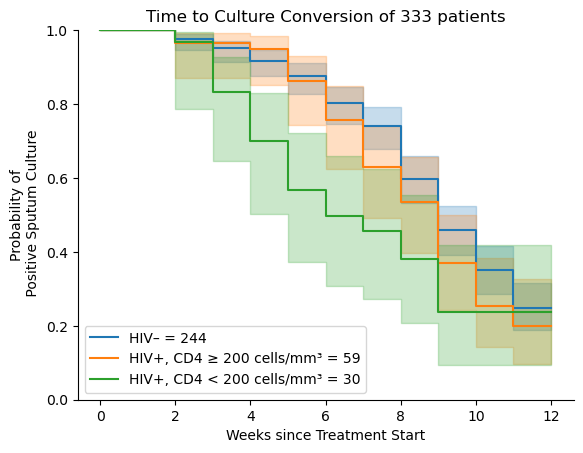

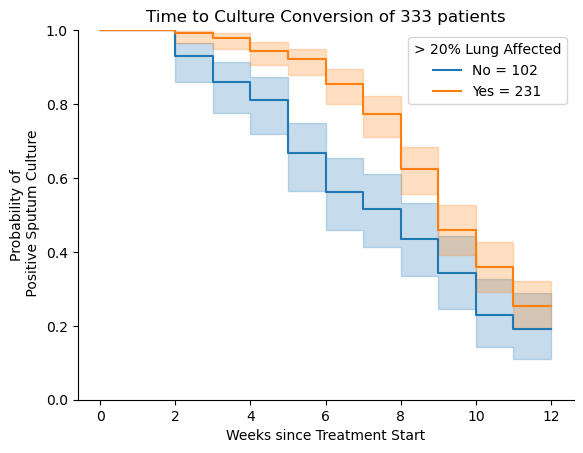

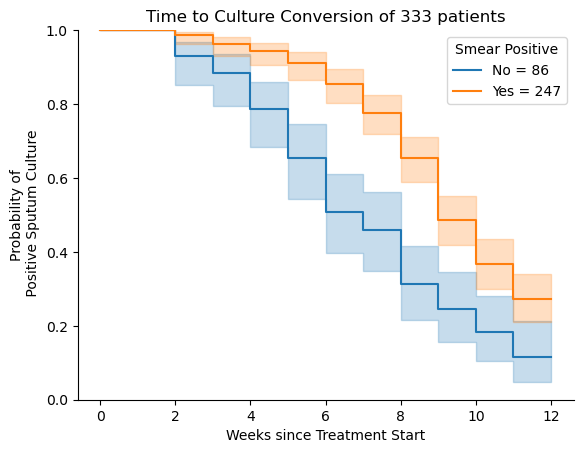

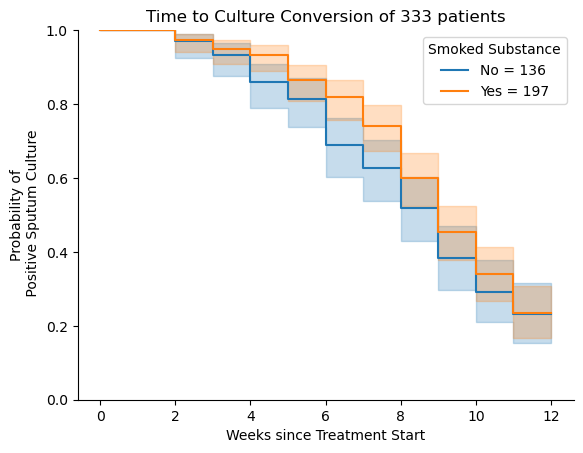

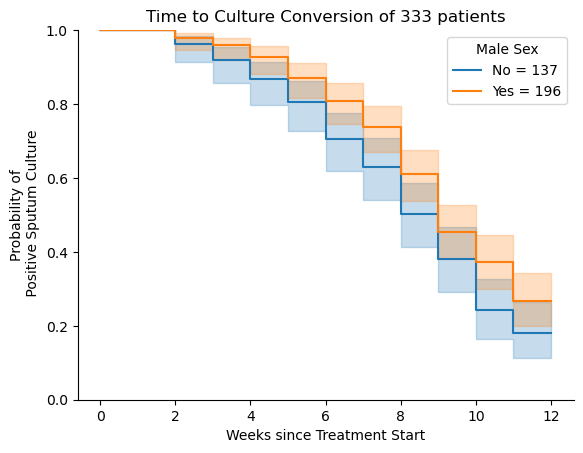

In [452]:
df_check_stratify_vars = df_add_metric_for_model.merge(df_TCC, on='pid')
df_check_stratify_vars['high_lung_involvement'] = (df_check_stratify_vars['predicted_PLI'] > 20)
df_check_stratify_vars['high_lung_involvement'] = df_check_stratify_vars['high_lung_involvement'].astype(int)

categorical_cols = ['HIV_CD4', 'high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1', 'smoked_substance_use', 'screen_sex']
labels_lst = ['HIV_CD4', '> 20% Lung Affected', 'Smear Positive', 'Smoked Substance', 'Male Sex']

legend_name_dict = dict(zip(categorical_cols, labels_lst))

df_logrank_pvalues = pd.DataFrame(columns = ['covariate', 'pval']).set_index('covariate')

for variable in categorical_cols:
    
    fig, ax = plt.subplots()
    
    df_single_variable = df_check_stratify_vars.dropna(subset=variable)
    df_single_variable[variable] = df_single_variable[variable].astype(int)
    
    if variable == 'HIV_CD4':
        legend_marker_dict = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200 cells/mm\u00B3', 2: 'HIV+, CD4 < 200 cells/mm\u00B3'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))
    # elif variable == 'Lineage 2':
    #     legend_marker_dict = {1: 'L1', 2: 'L2', 3: 'L3', 4: 'L4'}
    #     color_dict = {1: "#DF83AC", 2: "#7098CB", 3: "#815D9F", 4: "#E76956"}
    else:
        legend_marker_dict = {0: 'No', 1: 'Yes'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

    # sort so that 0 is plotted before 1
    for group in np.sort(df_single_variable[variable].unique()):
        
        df_single_group = df_single_variable.query(f"{variable}==@group")
            
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
            
        kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{legend_marker_dict[group]} = {len(df_single_group)}")

        if variable != 'HIV_CD4':
            plt.legend(title=legend_name_dict[variable])

    # HIV with high CD4 and HIV-negative are not significantly different, so just compare HIV with low CD4 to the other 2 groups
    if variable == 'HIV_CD4':
        
        # do them separately for each of the two HIV groups relative to the no HIV group
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_High_CD4', :] = logRank_test_results.p_value
        
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==2")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==2")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_Low_CD4', :] = logRank_test_results.p_value
        
    else:
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )

    # print(f"{legend_name_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")
    plt.ylim(0, 1)

    sns.despine()
    plt.title(f"Time to Culture Conversion of {df_single_variable.pid.nunique()} patients")
    plt.ylabel("Probability of\n Positive Sputum Culture") #
    plt.xlabel("Weeks since Treatment Start")
    sns.despine()
    
    if variable != 'HIV_CD4':
        df_logrank_pvalues.loc[variable, :] = logRank_test_results.p_value
    
    if variable in stratify_covariates:
        # plt.show()
        plt.savefig(f"/home/sak0914/MtbLongitudinalDiversity/results/figures/TCC/KM_estimate_stratified_{legend_name_dict[variable]}.svg", bbox_inches='tight')
    else:
        plt.close()
    
# df_logrank_pvalues.to_csv("/home/sak0914/MtbLongitudinalDiversity/results/TCC/KM_logRank_test_pvalues.csv")

In [453]:
df_logrank_pvalues

,pval
covariate,
HIV_High_CD4,0.218933
HIV_Low_CD4,0.003277
high_lung_involvement,0.000353
smear_pos_no_contam_sputum_specimen_1,0.0
smoked_substance_use,0.189838
screen_sex,0.021793


## Composite Poor Outcomes

In [368]:
# to_studyto_treatment_outcome column. 
# Other descriptions in to_studyto_other_treatment_outcome
# additional comments in to_comments_treatment_outcome
treatment_outcome_dict = {1: 'cure',
                          2: 'complete',
                          3: 'defaulted', # typically they stopped taking treatment entirely, not just interruption. May have been doctor-recommended, like due to liver injury or something
                          4: 'failure',
                          5: 'extension',
                          6: 'death',
                          7: 'transferred',
                          8: 'lost_fu',
                          9: 'other'
                        }

# esp_reason_end_of_study_parti column
# Other descriptions in esp_reasonoth_end_of_study_parti
esp_dict = {1: 'complete', # completed all study requirements
            2: 'inappropriate', # should not have been included in the study
            3: 'withdrew',
            4: 'failure', # includes both groups 4 and 5 in treatment_outcome_dict, meaning the patient was culture positive at month 5 or tx was extended
            5: 'relapse',
            6: 'moved', # moved/transferred out,
            7: 'lost_fu',
            8: 'death',
            9: 'other'
            }

cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            # 'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'adherence_rate_by_observed',
            'high_lung_involvement',
            'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
            # 'F2',
            # 'MixedInfect'
           ]

tb_deaths_only = True

# try these first, as they were required for the full TCC model
stratify_covariates = []

MIC_type = 'predicted'

df_tx_outcomes_full = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv")
df_tx_outcomes = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv").query("pid in @df_pids_for_outcomes_model.pid")

df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'event'] = 0
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'censor_date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['esp_date_end_of_study_parti']
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['time_in_trial']

df_tx_outcomes['weeks'] = df_tx_outcomes['date'] / 7
df_tx_outcomes['months'] = df_tx_outcomes['date'] / 30

print(f"Maximum event date: {df_tx_outcomes.weeks.max()} weeks")

Maximum event date: 99.0 weeks


In [229]:
# df_lowAF_variants_baseline.query("GENE in ['sugI', 'dacB1-sugI']")

In [317]:
df_tx_outcomes.query("TB_death != 0 & event == 1").event_type.value_counts()

event_type
relapse       13
tx_failure    12
death          3
Name: count, dtype: int64

In [121]:
binary_cols = ['diabetes', 'bl_prevtb', 'underweight']

for col in binary_cols:
    print(col, df_pids_for_outcomes_model[col].mean())

diabetes 0.046875
bl_prevtb 0.3854166666666667
underweight 0.5416666666666666


In [122]:
df_pids_for_outcomes_model['screen_years'].min(), df_pids_for_outcomes_model['screen_years'].median()

(15, 37.0)

In [123]:
df_pids_for_outcomes_model['HIV_CD4'].value_counts()

HIV_CD4
0.0    277
1.0     65
2.0     37
Name: count, dtype: int64

Text(0.5, 1.0, 'KM Estimate for 379 pids')

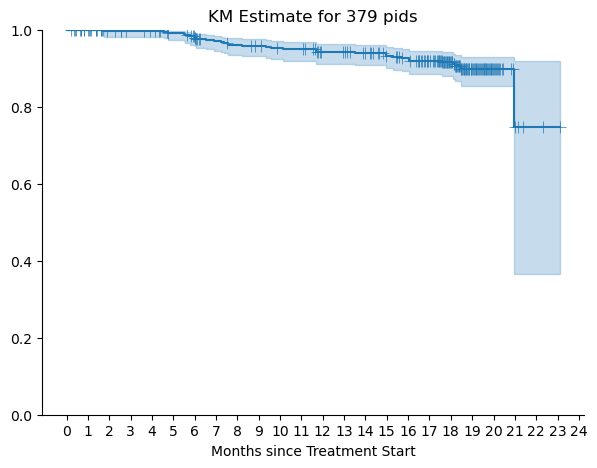

In [67]:
fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_tx_outcomes.months.max()))

kmf = lifelines.KaplanMeierFitter()

kmf.fit(df_tx_outcomes['months'], event_observed=df_tx_outcomes['event'],)# label=group_name)

kmf.plot_survival_function(ax=ax, 
                           show_censors=True, 
                           censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                           # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                          )

# Original event table (indexed by actual event/censor times)
event_table = kmf.event_table

# Define integer time points of interest
integer_times = np.arange(0, max_val + 1)

# Reindex to integer times
event_table_int = (
    event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
)

# Now you can extract at-risk and censored at integer times
at_risk_int = event_table_int["at_risk"]
censored_int = event_table_int["censored"]

every_other_month = np.linspace(0, max_val, 13)

sns.despine()
ax.get_legend().remove()
plt.xlabel('Months since Treatment Start')
ax.set_xticks(range(0, max_val + 1))

plt.ylim(0, 1)
plt.title(f"KM Estimate for {df_tx_outcomes.pid.nunique()} pids")
# plt.savefig("../results/figures/outcomes/baseline/KM_estimate.svg", bbox_inches='tight')

In [125]:
event_table_int[['at_risk', 'censored']].loc[every_other_month].T

event_at,0,2,4,6,8,10,12,14,16,18,20,22,24
at_risk,379,354,347,331,317,310,299,291,275,197,22,3,1
censored,0,1,1,1,0,1,1,1,1,4,1,1,1


In [323]:
df_pids_for_outcomes_model.shape, df_pids_for_outcomes_model.pid.nundique()

((405, 7900), 400)

In [344]:
df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,#.query("pid in @pids_with_low_F2"),
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                  df_tx_outcomes,
                                                                                                  cols_lst + ['RIF_AUC'],
                                                                                                  event_col = 'event',
                                                                                                  time_col = 'date',
                                                                                                  MIC_type=MIC_type,
                                                                                                 include_drugs=['RIF'],
                                                                                                 binarize_drugs=['RIF'],
                                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                                  invert_OR=False,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True
                                                                                                 )


# convert to HR per 10 years
OR_col = 'OR'
df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

df_violating_covariates = []

for model_idx in range(len(cph_model)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)
print(len(df_violating_covariates.query("p <= 0.05")))

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

base_model_LL = cph_model.log_likelihood_

    Censored 6 patients with non-TB deaths
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 37.2% are high
    385 total pids
Proportional hazard assumption looks okay.
    AIC: 314.8880845757591
    Concordance Index: 0.7594518536645051
    Log Likelihood: -140.44404228787954


In [345]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': 'PLI > 20%',
               'Not_Lineage_2': 'Not Lineage 2',
               'NumVar': '# of low-AF Segregating Sites',
               'NumVar1': '# of low-AF Sites at Baseline',
               'ChangeSites': '# of low-AF Sites with a Change',
               'underweight': 'BMI < 18',
               'adherence_rate_by_observed': 'Tx Adherence',
               'SASE1': 'Site-Averaged Shannon Entropy at Baseline'
             }

In [346]:
OR_col = 'OR'

df_test_results.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

,pval,covariate,OR_lower,OR,OR_upper
7,0.002995,HIV_Low_CD4,1.701114,4.777888,13.419566
2,0.004804,high_lung_involvement,0.128264,0.297732,0.691109
10,0.025073,RIF_pred_MIC_high,1.198170,4.241607,15.015592


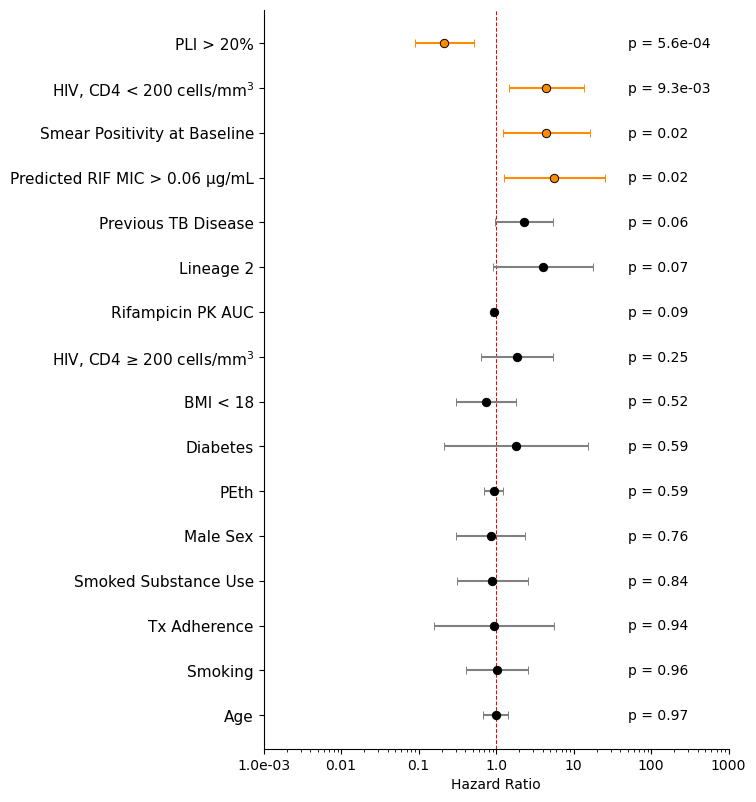

In [96]:
forest_plot(df_test_results, 
            df_test_results.sort_values(['pval', 'OR'], ascending=[True, False]).covariate.values, 
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=2, 
            df_stratify_variables_results=None, 
            # saveName="../results/figures/outcomes/baseline/forest_plot.svg"
           )


In [390]:
# diversity_metric = 'ChangeSites'

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

# sns.histplot(df_add_metric_for_model,
#              x=diversity_metric,
#              hue='Lineage',
#              multiple='dodge',
#              # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2), discrete=True
#             )

# plt.axvline(8, color='red', label="8")
# plt.legend()

# plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")

# sns.despine()
# plt.savefig(f"../results/figures/change_sites.svg", bbox_inches='tight')

In [391]:
# diversity_metric = 'NumVar'

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

# sns.histplot(df_add_metric_for_model,
#              x=diversity_metric,
#              hue='Lineage',
#              multiple='dodge',
#              # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2), discrete=True
#             )

# plt.axvline(9, color='red', label="9")
# plt.legend()

# plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")

# sns.despine()
# plt.savefig(f"../results/figures/segregating_sites.svg", bbox_inches='tight')

In [299]:
diversity_metric = 'NumVar1'
# diversity_metric = 'SASE1'
binarize = False
thresh = 0.1

# grouped_variant_genes = ['Rv2690c'] #['phoR'] #['sugI'] #['devS', 'devR']

# df_LAF['grouped_variant'] = df_LAF['pid'].isin(df_lowAF_variants.query("GENE in @grouped_variant_genes").pid.unique()).astype(int)
# df_LAF_baseline['grouped_variant'] = df_LAF_baseline['pid'].isin(df_lowAF_variants_baseline.query("GENE in @grouped_variant_genes").pid.unique()).astype(int)

# print(df_LAF_baseline.grouped_variant.value_counts())

# diversity_metric = 'ChangeSites'
# binarize = True
# thresh = 8

# diversity_metric = 'NumVar'
# binarize = True
# thresh = 9

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric, 'grouped_variant']])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric, 'grouped_variant']])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

if binarize:
    df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
    
    median_val = df_add_metric_for_model[diversity_metric].median()
    # df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > median_val).astype(int)

df_test_results_diversity, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                              df_pred_combined, 
                                                                TRUST_phenos,
                                                              df_tx_outcomes,
                                                           cols_lst + [diversity_metric] + ['RIF_AUC'],
                                                                                    # cols_lst + ['grouped_variant'] + ['RIF_AUC'],
                                                              event_col = 'event',
                                                              time_col = 'date',
                                                           MIC_type=MIC_type,
                                                             include_drugs=['RIF'],
                                                             binarize_drugs=['RIF'],
                                                              tb_deaths_only=tb_deaths_only,
                                                              invert_OR=False,
                                                              stratify_variables=stratify_covariates,
                                                             binary_lineage=True
                                                             )

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

OR_col = 'OR'

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

diversity_metric_continuous_LL = cph_model.log_likelihood_

# scale the odds ratio to be for an increase of 5 variable sites
if not binarize:
    scale_factor = 10
    df_test_results_diversity.loc[df_test_results_diversity['covariate']==diversity_metric, [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate']==diversity_metric, [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor
    df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

print(f"Final: {df_model_processed.pid.nunique()} pids")

    Censored 6 patients with non-TB deaths
Binarized RIF_pred_MIC at 0.05999994 µg/mL, 36.4% are high
    267 total pids
Proportional hazard assumption looks okay.
    AIC: 203.39831852578922
    Concordance Index: 0.8475639170284611
    Log Likelihood: -84.69915926289461
Final: 267 pids


In [300]:
df_test_results_diversity.query("pval <= 0.05").sort_values(['pval'])

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
2,high_lung_involvement,-0.939595,0.390786,0.241635,-2.142298,0.550934,1,0.000101,0.117385,0.039871,0.345595
4,NumVar1,0.554234,1.740608,0.172347,0.246974,0.076800,1,0.001301,11.819353,2.623435,53.249698
11,RIF_pred_MIC_high,1.501358,4.487779,0.468196,3.130074,0.976108,1,0.001343,22.875683,3.376834,154.966702
6,Lineage_2,1.454451,4.282132,0.485850,2.904448,0.970212,1,0.002757,18.255160,2.726088,122.245092
8,HIV_Low_CD4,0.426672,1.532151,0.170289,1.910587,0.762535,1,0.012225,6.757051,1.515955,30.118139
12,bl_prevtb,0.608721,1.838079,0.277695,1.243835,0.567430,1,0.028376,3.468891,1.140756,10.548441


In [308]:
# Cox Snell Pseudo R^2.
# There is not a good consensus on how to compute R^2 for survival regression models, so I picked this one
1 - np.exp(2/len(df_model_processed) * (base_model_LL - diversity_metric_continuous_LL))

0.03871507647243133

In [309]:
def LRT(LL_1, LL_2):
    
    test_stat = np.abs(2 * (LL_1 - LL_2))

    # p-value from the chi-squared distribution
    return 1 - st.chi2.cdf(test_stat, 1)

In [310]:
LRT(diversity_metric_continuous_LL, base_model_LL)

0.000983583195920179

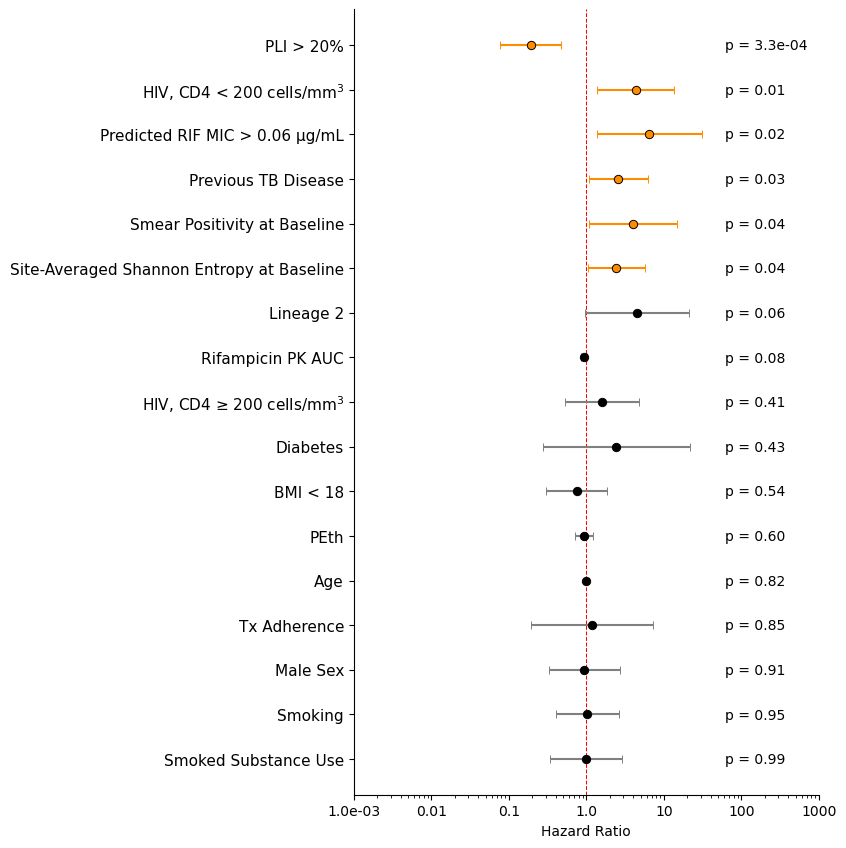

In [131]:
if binarize:
    saveName = f"../results/figures/outcomes/NumVar1_binarized_{thresh}.svg"
else:
    saveName = f"../results/figures/outcomes/NumVar1_continuous.svg"

forest_plot(df_test_results_diversity, 
            df_test_results_diversity.sort_values(['pval', 'OR'], ascending=[True, False]).covariate.values, 
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True,
            pval_offset=2, 
            df_stratify_variables_results=None, 
            # saveName=saveName
           )



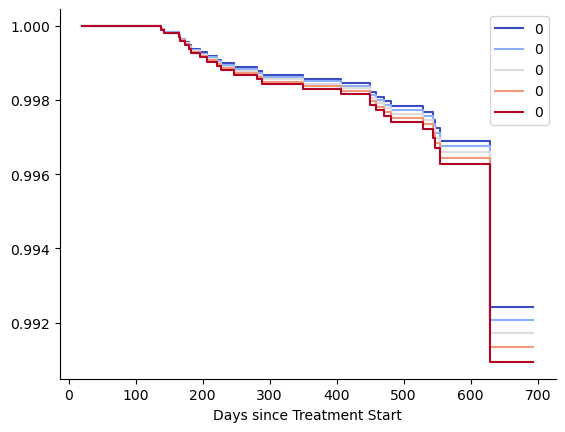

In [133]:
scaler = StandardScaler()

raw_values = df_add_metric_for_model.query("pid in @df_model_processed.pid")[diversity_metric].values

raw_mean = raw_values.mean()
raw_sd = raw_values.std()

scaled_values = (raw_values - raw_mean) / raw_sd

def unscale_val(scaled_val, raw_mean, raw_sd):
    # it should be an integer, so return it as such. If it's not, it's a float precision problem
    return int(scaled_val * raw_sd + raw_mean)

# percentiles_lst = [25, 50, 75, 87.5, 100]

# if binarize:
#     test_vals = df_model_processed[diversity_metric].unique()
# else:
#     test_vals = np.percentile(scaled_values, percentiles_lst)
    
# percentile_dict = dict(zip(test_vals, percentiles_lst))

# test_vals = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
test_vals = np.array([0, 0.05, 0.1, 0.15, 0.2])
test_vals = (test_vals - raw_mean) / raw_sd

ax = cph_model.plot_partial_effects_on_outcome(covariates=diversity_metric, values=test_vals, plot_baseline=False, cmap='coolwarm')

# Update legend labels
handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles, [f"{perc}th perc. = {str(unscale_val(val, raw_mean, raw_sd))}" for val, perc in percentile_dict.items()])
ax.legend(handles, [f"{str(unscale_val(val, raw_mean, raw_sd))}" for val in test_vals])
ax.set_xlabel('Days since Treatment Start')

sns.despine()
# plt.savefig("../results/figures/outcomes/NumVar1_varying_hazard.svg", bbox_inches='tight')

# Binarized NumVar1

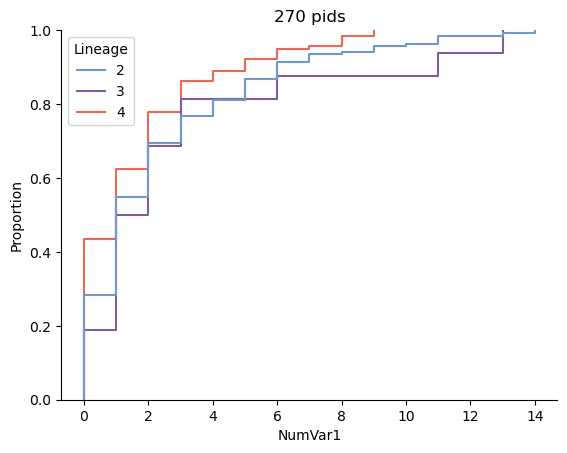

In [485]:
diversity_metric = 'NumVar1'

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric]]).query("pid in @pids_with_same_lineage_and_low_F2")#.merge(df_LAF[['pid', col_to_binarize]])


LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   # "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }
    
sns.ecdfplot(df_add_metric_for_model,
             x=diversity_metric,
             hue='Lineage',
             hue_order=['2', '3', '4'],
             palette=LinToColor_Dict
            )

binarize_thresh = 4
# plt.axvline(binarize_thresh, color='black', label=str(binarize_thresh))
# plt.legend()

plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")

sns.despine()
# plt.savefig(f"../results/figures/variable_sites_sample1.svg", bbox_inches='tight')

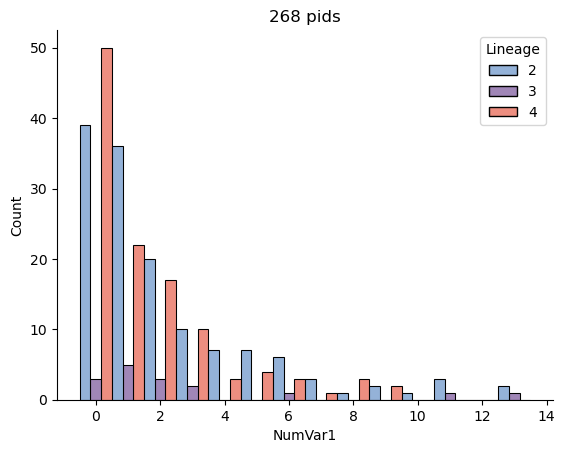

In [104]:
diversity_metric = 'NumVar1'

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric]]).query("pid in @pids_with_same_lineage_and_low_F2")#.merge(df_LAF[['pid', col_to_binarize]])

df_add_metric_for_model = df_add_metric_for_model.query("pid in @df_model_processed.pid")

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   # "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }
    
sns.histplot(df_add_metric_for_model,
             x=diversity_metric,
             hue='Lineage',
             multiple='dodge',
             bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2), discrete=True,
             hue_order=['2', '3', '4'],
             palette=LinToColor_Dict
            )

binarize_thresh = 4
# plt.axvline(binarize_thresh, color='black', label=str(binarize_thresh))
# plt.legend()

plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")

sns.despine()
plt.savefig(f"../results/figures/variable_sites_sample1.svg", bbox_inches='tight')

In [105]:
# diversity_metric = 'NumVar1'
# binarize = True
# thresh = 4

# # diversity_metric = 'ChangeSites'
# # binarize = True
# # thresh = 8

# # diversity_metric = 'NumVar'
# # binarize = True
# # thresh = 9

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

# if binarize:
#     df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
    
#     median_val = df_add_metric_for_model[diversity_metric].median()
#     # df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > median_val).astype(int)

# df_test_results_diversity, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,
#                                                               df_pred_combined, 
#                                                                 TRUST_phenos,
#                                                               df_tx_outcomes,
#                                                            cols_lst + [diversity_metric] + ['RIF_AUC'],
#                                                            #  [diversity_metric],
#                                                               event_col = 'event',
#                                                               time_col = 'date',
#                                                            MIC_type=MIC_type,
#                                                              include_drugs=['RIF'],
#                                                              binarize_drugs=['RIF'],
#                                                               tb_deaths_only=tb_deaths_only,
#                                                               invert_OR=False,
#                                                               # stratify_variables=['RIF_pred_MIC_high'],
#                                                              binary_lineage=True
#                                                              )

# df_model_processed = df_model_processed[0]
# cph_model = cph_model[0]

# OR_col = 'OR'

# cph_model.check_assumptions(df_model_processed)
# print(f"    AIC: {cph_model.AIC_partial_}")
# print(f"    Concordance Index: {cph_model.concordance_index_}")
# print(f"    Log Likelihood: {cph_model.log_likelihood_}")

# diversity_metric_binarized_LL = cph_model.log_likelihood_

# # scale the odds ratio to be for an increase of 5 variable sites
# if not binarize:
#     scale_factor = 10
#     df_test_results_diversity.loc[df_test_results_diversity['covariate']==diversity_metric, [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate']==diversity_metric, [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor
#     df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate']=='screen_years', [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

# print(f"Final: {df_model_processed.pid.nunique()} pids")

In [106]:
# if binarize:
#     saveName = f"../results/figures/outcomes/NumVar1_binarized_{thresh}.svg"
# else:
#     saveName = f"../results/figures/outcomes/NumVar1_continuous.svg"

# forest_plot(df_test_results_diversity, 
#             df_test_results_diversity.sort_values(['pval', 'OR'], ascending=[True, False]).covariate.values, 
#             labels_dict, 
#             val_col='OR', 
#             alpha=0.05, 
#             log=True, 
#             pval_offset=2, 
#             df_stratify_variables_results=None, 
#             saveName=saveName
#            )



In [207]:
def bin_by_min_count(values, min_count):
    """
    Group sorted values into bins with at least `min_count` elements.
    
    Parameters
    ----------
    values : array-like
        The input values.
    min_count : int
        Minimum number of elements per bin.
        
    Returns
    -------
    bins : list of arrays
        A list of arrays, each containing the values in that bin.
    edges : list of tuples
        (min, max) range for each bin.
    """
    values = np.sort(values)
    n = len(values)
    
    # Determine split indices
    splits = np.arange(min_count, n, min_count)
    bins = np.split(values, splits)
    
    # Merge last bin if it's too small
    if len(bins[-1]) < min_count and len(bins) > 1:
        bins[-2] = np.concatenate([bins[-2], bins[-1]])
        bins = bins[:-1]
    
    edges = [(b[0], b[-1]) for b in bins]
    return bins, edges

227
41
NumVar1_Binary: p = 0.00023170724168534318


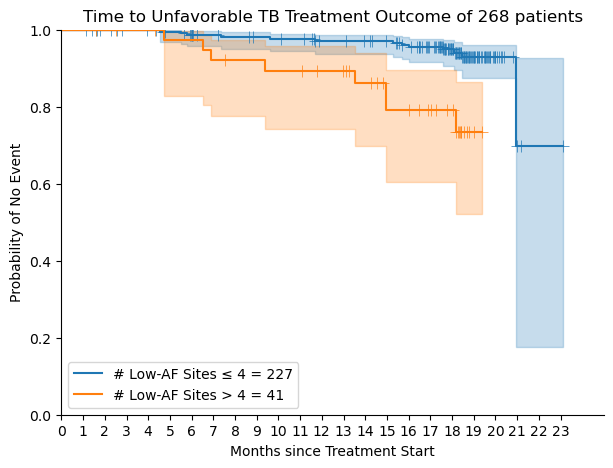

In [109]:
thresh = 4

df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

# it's the binarized one here, not raw values
del df_KM_plot[diversity_metric]

# get raw values
df_KM_plot = df_KM_plot.merge(df_LAF[['pid', 'NumVar1']])

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = f'{diversity_metric}_Binary'
df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)

# stratify_col = diversity_metric

# stratify_col = f'{diversity_metric}_Stratified'

# percentiles = np.percentile(df_KM_plot[diversity_metric], [25, 50, 75])
# stratify_iter = 0

# for i, perc in enumerate(percentiles):
#     df_KM_plot.loc[(df_KM_plot[diversity_metric] >= perc), stratify_col] = stratify_iter
#     stratify_iter += 1

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))
    group_name = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}[group]

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               label=f"{group_name} = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0, 1)

logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_KM_plot.query(f"{stratify_col}==1")['date'], 
                                                                  durations_B=df_KM_plot.query(f"{stratify_col}==0")['date'], 
                                                                  event_observed_A=df_KM_plot.query(f"{stratify_col}==1")['event'], 
                                                                  event_observed_B=df_KM_plot.query(f"{stratify_col}==0")['event'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )

print(f"{stratify_col}: p = {logRank_test_results.p_value}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

sns.despine()
plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')

# Sites with changes in many pids

In [27]:
def get_SNP_changes_single_pid(pid, df, AF_thresh=0.95, change_thresh=0):
    '''
    This function returns all sites where either Sample 1 or Sample 2 is unfixed. 
    '''
    
    # remove sites that are fixed (AF > 0.95) in both. Keep those that are fixed in one and not the other though
    single_pid_results = pd.DataFrame(sample_1_SNPs.loc[pid]).rename(columns={pid: 'Sample1'})
    single_pid_results = single_pid_results.merge(pd.DataFrame(sample_2_SNPs.loc[pid]).rename(columns={pid: 'Sample2'}), left_index=True, right_index=True)
    single_pid_results = single_pid_results.merge(pd.DataFrame(SNP_differences.loc[pid]).query(f"{pid} != 0").rename(columns={pid: 'Diff'}), left_index=True, right_index=True)

    single_pid_results = single_pid_results.loc[(single_pid_results['Diff'] >= change_thresh) | 
                                                (single_pid_results['Diff'] <= -change_thresh)
                                               ].query("~(Sample1 > @AF_thresh & Sample2 > @AF_thresh)")

    # add SNP effects
    single_pid_results = single_pid_results.merge(df[['POS', 'SNP', 'GENE', 'Variant_Type']].drop_duplicates(), left_index=True, right_on='SNP')#.set_index('SNP')

    single_pid_results['PositiveChange'] = (single_pid_results['Diff'] > 0).astype(int)
    
    return single_pid_results

In [28]:
df_large_SNP_changes = []

for pid in pids_with_same_lineage_and_low_F2:
    
    single_pid_results = get_SNP_changes_single_pid(pid, df_variants.query("Variant_Type != 'Silent'"))
    single_pid_results['pid'] = pid
    
    df_large_SNP_changes.append(single_pid_results)
    
df_large_SNP_changes = pd.concat(df_large_SNP_changes)
df_large_SNP_changes['Abs_Diff'] = np.abs(df_large_SNP_changes['Diff'])

df_large_SNP_changes.pid.nunique()

223

In [236]:
# change_thresh = 0.1

# # pd.DataFrame(df_large_SNP_changes.query("Abs_Diff > @change_thresh")['GENE'].value_counts()).query("count > 1")#.shape

# genes_with_large_changes = pd.DataFrame(df_large_SNP_changes.query("Abs_Diff > @change_thresh").groupby(['GENE', 'Variant_Type']).pid.nunique()).query("pid > 1 & Variant_Type != 'Intergenic'").index.values

# intergenic_regions_with_large_changes = pd.DataFrame(df_large_SNP_changes.query("Abs_Diff > @change_thresh").groupby(['GENE', 'Variant_Type']).pid.nunique()).query("pid > 1 & Variant_Type == 'Intergenic'").reset_index()['GENE'].values

# pd.DataFrame(df_large_SNP_changes.query("Abs_Diff > @change_thresh").groupby(['GENE', 'Variant_Type']).pid.nunique()).query("pid > 1 & Variant_Type == 'Intergenic'")

In [29]:
change_thresh = 0.1
df_pos_large_changes = pd.DataFrame(df_large_SNP_changes.query("Abs_Diff > @change_thresh").groupby(['GENE', 'SNP', 'Variant_Type']).pid.nunique()).query("pid > 1").reset_index()

pos_with_large_changes = df_pos_large_changes.SNP.values 

df_pos_large_changes = df_pos_large_changes.sort_values(['pid', 'SNP'], ascending=False).reset_index(drop=True)

for i, row in df_pos_large_changes.iterrows():
    
    SNP = row['SNP']
    df_change_query = df_large_SNP_changes.query("Abs_Diff > @change_thresh & SNP==@SNP")
    
    df_change_query = df_change_query.merge(df_longitudinal_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage']])
    
    df_pos_large_changes.loc[i, ['NumGain', 'NumLoss', 'Lineages']] = [df_change_query.query("PositiveChange == 1").pid.nunique(), 
                                                           df_change_query.query("PositiveChange == 0").pid.nunique(),
                                                           ','.join(df_change_query['Lineage'].unique())
                                                          ]
    
df_pos_large_changes[['NumGain', 'NumLoss']] = df_pos_large_changes[['NumGain', 'NumLoss']].astype(int)

In [32]:
df_pos_large_changes

,GENE,SNP,Variant_Type,pid,NumGain,NumLoss,Lineages
0,sugI,3717105_C_T,Nonsense,10,2,8,"2,4"
1,sugI,3717108_C_A,Missense,5,2,3,2
2,sugI,3717109_C_A,Missense,4,1,3,2
3,uspC,2591484_G_A,Missense,3,1,2,2
4,Rv0457c-Rv0458,549637_G_A,Intergenic,2,0,2,2
5,fbpD-fbpA,4265593_G_T,Intergenic,2,2,0,2
6,Rv3517,3953969_G_T,Missense,2,0,2,4
7,sugI,3717219_C_A,Missense,2,1,1,2
8,dacB1-sugI,3717087_C_A,Intergenic,2,0,2,2
9,subI,2697452_A_G,Missense,2,1,1,2


In [93]:
L2_baseline_samples = df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2 & Lineage in [2, '2'] & Paired_Sample_Num==1").SampleID.values

os.makedirs("/home/sak0914/MtbLongitudinalDiversity/results/L2_baseline_samples", exist_ok=True)

with open(f"/home/sak0914/MtbLongitudinalDiversity/results/L2_baseline_samples/VCF_fNames.txt", "w+") as file:
    for sample in L2_baseline_samples:
        file.write(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.eff.vcf\n")

NOTE: MFS-575.excludeLowConf is identical to MFS-16.excludeLowConf but kept for subsequent analysis

NOTE: MFS-868.excludeLowConf is identical to MFS-58.excludeLowConf but kept for subsequent analysis

NOTE: MFS-452.excludeLowConf is identical to MFS-64.excludeLowConf but kept for subsequent analysis

NOTE: MFS-646.excludeLowConf is identical to MFS-625.excludeLowConf but kept for subsequent analysis

NOTE: 1 identical sequences (see below) will be ignored for subsequent analysis

NOTE: MFS-777.excludeLowConf (identical to MFS-625.excludeLowConf) is ignored but added at the end

In [302]:
identical_WGS_sample_pairs = [['MFS-575', 'MFS-16'], ['MFS-868', 'MFS-58'], ['MFS-452', 'MFS-64'], ['MFS-646', 'MFS-625'], ['MFS-777', 'MFS-625']]

for sample_1, sample_2 in identical_WGS_sample_pairs:
    
    pid_1 = df_longitudinal_pids.query("SampleID==@sample_1").pid.values[0]
    pid_2 = df_longitudinal_pids.query("SampleID==@sample_2").pid.values[0]
    
    unique_households = df_trust_patients.query("pid in [@pid_1, @pid_2]").bl_housecode.dropna().unique()
    
    if len(unique_households) > 0:
        print(sample_1, sample_2, ','.join(unique_households))

MFS-868 MFS-58 F1
MFS-452 MFS-64 Y


In [68]:
df_lowAF_variants.query("GENE=='sugI' & SampleID=='MFS-156'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,False_in_all_Ground_Truth_Samples,predicted,pred_class,Paired_Sample_Num,SNP,Region,Variant_Type,REF_AA,ALT_AA,F2 > 0.03
1447,3717105,C,T,0.0,sugI,c.16C>T,p.Gln6*,1,436,436.0,...,0.0,0.950544,1.0,1,3717105_C_T,sugI,Nonsense,Gln,n6*,0


In [69]:
df_lowAF_variants.query("GENE=='sugI' & SampleID=='MFS-166'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,False_in_all_Ground_Truth_Samples,predicted,pred_class,Paired_Sample_Num,SNP,Region,Variant_Type,REF_AA,ALT_AA,F2 > 0.03


In [65]:
df_large_SNP_changes.query("")

,Sample1,Sample2,Diff,POS,SNP,GENE,Variant_Type,PositiveChange,pid,Abs_Diff
76252,0.000000,0.064935,0.064935,1350707,1350707_G_A,fadD6,Missense,1,T0269,0.064935
76251,0.000000,0.050802,0.050802,137278,137278_A_G,gca-gmhA,Intergenic,1,T0269,0.050802
76253,0.000000,0.058594,0.058594,3707493,3707493_C_T,sdhB,Missense,1,T0269,0.058594
499,1.000000,0.898917,-0.101083,1774659,1774659_C_T,Rv1566c-Rv1567c,Intergenic,0,T0447,0.101083
760,1.000000,0.943038,-0.056962,2740693,2740693_T_C,rplU-dctA,Intergenic,0,T0447,0.056962
...,...,...,...,...,...,...,...,...,...,...
539120,0.155015,0.000000,-0.155015,1811736,1811736_A_G,trpB,Missense,0,T0467,0.155015
539122,0.099071,0.168508,0.069437,3066058,3066058_C_A,Rv2752c,Missense,1,T0467,0.069437
540308,0.000000,0.054131,0.054131,3567129,3567129_G_A,Rv3197,Missense,1,T0467,0.054131
539127,0.168901,0.000000,-0.168901,3793685,3793685_G_A,dxs2,Missense,0,T0467,0.168901


In [108]:
region = 'sugI'

df_color = df_large_SNP_changes.query("Abs_Diff > @change_thresh & GENE==@region").merge(df_longitudinal_pids.query("Paired_Sample_Num==1"))

# df_color = pd.concat([df_color[['SampleID', 'Variant_Type']], 
#                       pd.DataFrame({'SampleID': df_longitudinal_pids.query("SampleID not in @df_color.SampleID.values & Paired_Sample_Num==1 & pid in @pids_with_same_lineage_and_low_F2 & Lineage == '2'").SampleID.values})]
#                     )

df_color['Variant_Type'] = df_color['Variant_Type'].fillna('NoVariant')

df_color['Variant_Type'] = df_color['Variant_Type'].map({'NoVariant': 0, 'Missense': 1, 'Nonsense': 2})

# drop duplicates, keeping the highest value if a sample has both missense and nonsense mutations
df_color = pd.DataFrame(df_color.groupby('SampleID')['Variant_Type'].max()).reset_index()

SNP_samples = [seq.id.replace('.excludeLowConf', '') for seq in SeqIO.parse("../results/L2_baseline_samples/SNP_concatenate_filtered.fasta", "fasta")]

df_color = df_color.query("SampleID in @SNP_samples")

print(df_color.SampleID.nunique(), len(df_color))

df_color.to_csv(f"../results/L2_baseline_samples/sugI_colored.tsv", index=False, sep='\t')

18 18


In [109]:
df_color = df_color.merge(df_longitudinal_pids[['pid', 'SampleID', 'Lineage']])
df_color.Lineage.value_counts()

Lineage
2    18
Name: count, dtype: int64

In [112]:
df_color.Variant_Type.value_counts()

Variant_Type
1    10
2     8
Name: count, dtype: int64

In [115]:
df_color.query("Variant_Type==1")

,SampleID,Variant_Type,pid,Lineage
0,MFS-115,1,T0200,2
1,MFS-123,1,T0214,2
2,MFS-129,1,T0220,2
5,MFS-166,1,T0251,2
6,MFS-182,1,T0264,2
7,MFS-388,1,T0324,2
10,MFS-444,1,T0359,2
12,MFS-471,1,T0378,2
16,MFS-777,1,T0384,2
17,MFS-806,1,T0425,2


In [357]:
df_large_SNP_changes.query("pid in ['T0218', 'T0329'] & GENE=='sugI'")

,Sample1,Sample2,Diff,POS,SNP,GENE,Variant_Type,PositiveChange,pid,Abs_Diff
22827,0.309577,0.0,-0.309577,3717105,3717105_C_T,sugI,Nonsense,0,T0218,0.309577
22827,0.101266,0.0,-0.101266,3717105,3717105_C_T,sugI,Nonsense,0,T0329,0.101266


In [340]:
df_color.Variant_Type.value_counts()

Variant_Type
0    251
1     11
2     10
Name: count, dtype: int64

In [341]:
df_color

,SampleID,Variant_Type
0,MFS-806,1
1,MFS-129,1
2,MFS-404,1
3,MFS-404,2
4,MFS-115,1
...,...,...
246,MFS-860,0
247,MFS-862,0
248,MFS-864,0
249,MFS-866,0


In [50]:
df_large_SNP_changes.query("(Diff > 0.1 | Diff < -0.1) & GENE==@search_gene")

,Sample1,Sample2,Diff,SNP,GENE,Variant_Type,PositiveChange,pid,Abs_Diff
120026,0.858779,0.000000,-0.858779,4338594_A_C,whiB6-Rv3863,Intergenic,0,T0280,0.858779
153096,0.691932,0.435835,-0.256096,4338646_T_C,whiB6-Rv3863,Intergenic,0,T0009,0.256096


In [44]:
search_gene = 'whiB6-Rv3863'

pids_with_change = df_large_SNP_changes.query("(Diff > 0.1 | Diff < -0.1) & GENE==@search_gene").pid.unique()

df_large_SNP_changes.query("(Diff > 0.1 | Diff < -0.1) & GENE==@search_gene")

,Sample1,Sample2,Diff,SNP,GENE,Variant_Type,PositiveChange,pid,Abs_Diff
120026,0.858779,0.000000,-0.858779,4338594_A_C,whiB6-Rv3863,Intergenic,0,T0280,0.858779
153096,0.691932,0.435835,-0.256096,4338646_T_C,whiB6-Rv3863,Intergenic,0,T0009,0.256096


In [611]:
for gene in genes_with_large_changes:
    pids_with_large_changes = df_large_SNP_changes.query("GENE == @gene & Abs_Diff > @change_thresh").pid.values
    print(gene, df_longitudinal_pids.query("pid in @pids_with_large_changes").Coll2014.unique())

PPE50 ['4.3.2.1' '3']
Rv0010c-Rv0011c ['2.2.1' '2.2.1.1']
Rv1532c ['2.2.1.1' '4.3.3']
Rv2345 ['2.2.1' '4.3.3']
Rv2690c ['4.4.1.1' '4.3.3']
Rv2820c ['2.2.1.1']
devS ['4.4.1.1' '4.3.2.1' '4.3.3' '2.2.1.1']
phoR ['2.2.1' '2.2.1.1']
subI ['2.2.1' '2.2.1.1']


In [38]:
df_longitudinal_pids.query("pid=='T0182'")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
238,T0182,S0182-01,MFS-623,1,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.006834,2,1,2
239,T0182,S0182-05,MFS-624,5,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.007751,2,2,2


In [619]:
df_variants.query("pid in @pids_with_change & GENE==@search_gene & Variant_Type != 'Silent'")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE', 'Variant_Type']]

,pid,SampleID,POS,REF,ALT,AF,GENE,Variant_Type
104609,T0294,MFS-283,851701,A,G,0.957831,phoP,Missense
226210,T0341,MFS-416,851982,G,T,0.747508,phoP,Missense
226372,T0341,MFS-417,851982,G,T,0.983713,phoP,Missense


In [618]:
df_longitudinal_pids.query("pid in @pids_with_change")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
384,T0294,S0294-01,MFS-282,1,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.008945,2,1,2
385,T0294,S0294-05,MFS-283,5,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.010115,2,2,2
424,T0341,S0341-01,MFS-416,1,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,0.006697,4,1,2
425,T0341,S0341-04,MFS-417,4,4.4.1.1,4.2.1.2.2.1.1,"stype,canetti",NaN,4,0.007156,4,2,2


In [428]:
df_large_SNP_changes.query("Diff > 0.1 | Diff < -0.1").query("PositiveChange==0")['GENE'].value_counts()

GENE
katG            3
Rv1194c         2
phoR            2
sugI            2
Rv1794-eccD5    2
               ..
lprF            1
Rv0472c         1
Rv0466          1
Rv3863          1
proB            1
Name: count, Length: 83, dtype: int64